In [11]:
# Import required libraries for data analysis and visualization
import os, glob, pandas as pd, seaborn as sns, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

In [12]:
import re

# Load master heatmap CSV files from current directory
csv_files = glob.glob("master_heatmap*.csv")  # Find all CSV files in current directory

def extract_teff_bin(filename):
    match = re.search(r'(\d{4})_(\d{4})_K', filename)
    if match:
        return f"{match.group(1)}_{match.group(2)}"
    return None

# Load and combine all CSV files into a single dataframe, adding temperature bin
df = pd.DataFrame()
for f in csv_files:
    temp_bin = extract_teff_bin(f)
    temp_df = pd.read_csv(f)
    temp_df['teff_bin'] = temp_bin
    df = pd.concat([df, temp_df], ignore_index=True)

print(f"Combined dataframe shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())



Combined dataframe shape: (504, 7)
Columns: ['True Radius (Earth Radii)', 'True Period (Days)', 'detections', 'trials', 'transit_prob', 'detection_rate', 'teff_bin']
   True Radius (Earth Radii)  True Period (Days)  detections  trials  \
0                        1.4               0.700          46      66   
1                        1.4               1.270          39      66   
2                        1.4               2.305          28      66   
3                        1.4               4.183          20      66   
4                        1.4               7.591          14      66   

   transit_prob  detection_rate   teff_bin  
0      0.252196        0.696970  4000_4500  
1      0.169538        0.590909  4000_4500  
2      0.113944        0.424242  4000_4500  
3      0.076585        0.303030  4000_4500  
4      0.051476        0.212121  4000_4500  


Period values: [ 0.7    1.27   2.305  4.183  7.591 13.776 25.   ]
Period log values: [-0.15490196  0.10380372  0.36267093  0.62148786  0.88029899  1.13912313
  1.39794001]
Period bin edges: [0.5196910044992892, 0.9428679653058534, 1.7109500284929424, 3.1051272115647697, 5.6349936113539645, 10.226124192478789, 18.55801713545928, 33.67816698508144]
Number of bins: 7


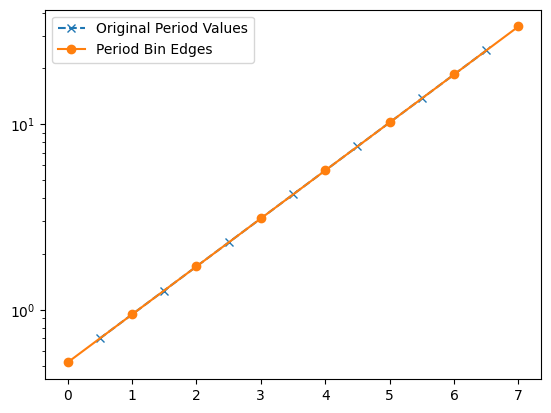

Radius values: [1.4  1.81 2.33 3.   3.88 5.  ]
Radius log values: [0.14612804 0.25767857 0.36735592 0.47712125 0.58883173 0.69897   ]
Radius bin edges: [1.231268492022562, 1.5918542646863123, 2.0536065835500237, 2.6438608132804573, 3.411744421846396, 4.404543109109048, 5.675957614831249]
Number of bins: 6


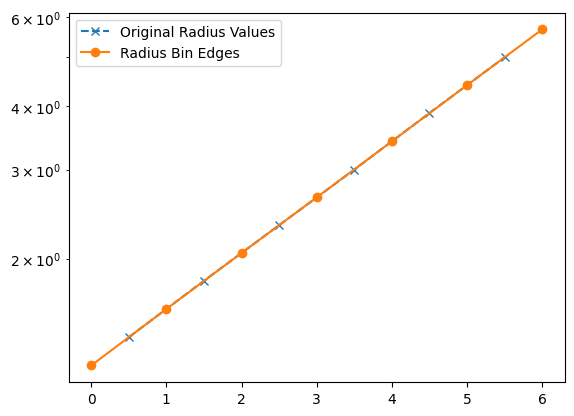

In [13]:
# Generate log-spaced bin edges for True Period values
period_vals = np.array(sorted(df['True Period (Days)'].unique()))  # Get unique period values

# Calculate log-space halfway points between adjacent values
period_log = np.log10(period_vals)  # Convert to log space
period_bin_edges = []

# First edge: extrapolate backward using same log spacing as first interval
log_step = period_log[1] - period_log[0]  # Log spacing between first two values
first_edge = 10**(period_log[0] - log_step/2)  # Extrapolate backward by half step
period_bin_edges.append(first_edge)

# Middle edges: halfway points in log space between adjacent values
for i in range(len(period_log) - 1):
    halfway_log = (period_log[i] + period_log[i+1]) / 2  # Midpoint in log space
    period_bin_edges.append(10**halfway_log)  # Convert back to linear space

# Last edge: extrapolate forward using same log spacing as last interval
log_step = period_log[-1] - period_log[-2]  # Log spacing between last two values
last_edge = 10**(period_log[-1] + log_step/2)  # Extrapolate forward by half step
period_bin_edges.append(last_edge)

# Print results for verification
print(f"Period values: {period_vals}")
print(f"Period log values: {period_log}")
print(f"Period bin edges: {period_bin_edges}")
print(f"Number of bins: {len(period_bin_edges) - 1}")

# Plot to visualize period values vs bin edges
period_vals_x_axis = np.arange(len(period_vals)) + 0.5  # Offset for visualization
plt.plot(period_vals_x_axis, period_vals, 'x--', label='Original Period Values')
plt.plot(period_bin_edges, 'o-', label='Period Bin Edges')
plt.legend()
plt.yscale('log')  # Log scale for better visualization
plt.show()

# Generate log-spaced bin edges for True Radius values (same method as periods)
radius_vals = np.array(sorted(df['True Radius (Earth Radii)'].unique()))  # Get unique radius values

# Calculate log-space halfway points between adjacent values
radius_log = np.log10(radius_vals)  # Convert to log space
radius_bin_edges = []

# First edge: extrapolate backward using same log spacing as first interval
log_step = radius_log[1] - radius_log[0]  # Log spacing between first two values
first_edge = 10**(radius_log[0] - log_step/2)  # Extrapolate backward by half step
radius_bin_edges.append(first_edge)

# Middle edges: halfway points in log space between adjacent values
for i in range(len(radius_log) - 1):
    halfway_log = (radius_log[i] + radius_log[i+1]) / 2  # Midpoint in log space
    radius_bin_edges.append(10**halfway_log)  # Convert back to linear space

# Last edge: extrapolate forward using same log spacing as last interval
log_step = radius_log[-1] - radius_log[-2]  # Log spacing between last two values
last_edge = 10**(radius_log[-1] + log_step/2)  # Extrapolate forward by half step
radius_bin_edges.append(last_edge)

# Print results for verification
print(f"Radius values: {radius_vals}")
print(f"Radius log values: {radius_log}")
print(f"Radius bin edges: {radius_bin_edges}")
print(f"Number of bins: {len(radius_bin_edges) - 1}")

# Plot to visualize radius values vs bin edges
radius_vals_x_axis = np.arange(len(radius_vals)) + 0.5  # Offset for visualization
plt.plot(radius_vals_x_axis, radius_vals, 'x--', label='Original Radius Values')
plt.plot(radius_bin_edges, 'o-', label='Radius Bin Edges')
plt.legend()
plt.yscale('log')  # Log scale for better visualization
plt.show()



In [14]:
# Assign bin min/max edges for each row using pd.cut with labels as bin index, then map to edge values
df['radius_bin'] = pd.cut(df['True Radius (Earth Radii)'], bins=radius_bin_edges, include_lowest=True, labels=False)
df['period_bin'] = pd.cut(df['True Period (Days)'], bins=period_bin_edges, include_lowest=True, labels=False)
df['radius_bin_min'] = df['radius_bin'].apply(lambda x: radius_bin_edges[int(x)] if pd.notnull(x) else np.nan)
df['radius_bin_max'] = df['radius_bin'].apply(lambda x: radius_bin_edges[int(x)+1] if pd.notnull(x) else np.nan)
df['period_bin_min'] = df['period_bin'].apply(lambda x: period_bin_edges[int(x)] if pd.notnull(x) else np.nan)
df['period_bin_max'] = df['period_bin'].apply(lambda x: period_bin_edges[int(x)+1] if pd.notnull(x) else np.nan)
print(df.head())

   True Radius (Earth Radii)  True Period (Days)  detections  trials  \
0                        1.4               0.700          46      66   
1                        1.4               1.270          39      66   
2                        1.4               2.305          28      66   
3                        1.4               4.183          20      66   
4                        1.4               7.591          14      66   

   transit_prob  detection_rate   teff_bin  radius_bin  period_bin  \
0      0.252196        0.696970  4000_4500           0           0   
1      0.169538        0.590909  4000_4500           0           1   
2      0.113944        0.424242  4000_4500           0           2   
3      0.076585        0.303030  4000_4500           0           3   
4      0.051476        0.212121  4000_4500           0           4   

   radius_bin_min  radius_bin_max  period_bin_min  period_bin_max  
0        1.231268        1.591854        0.519691        0.942868  
1        1

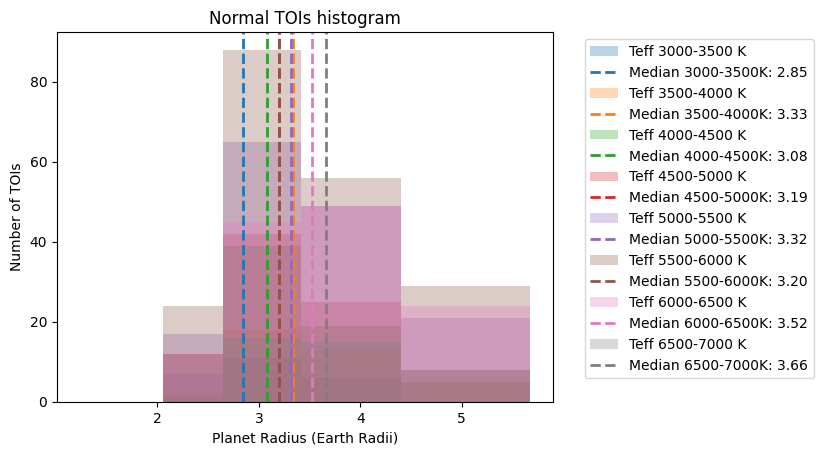

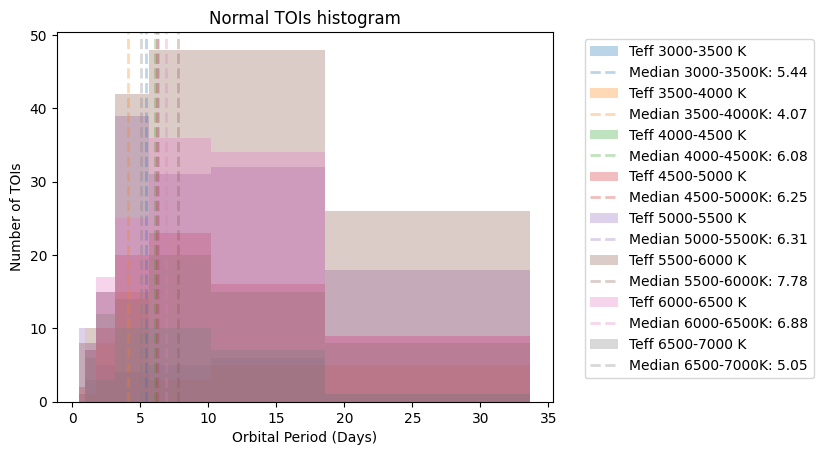

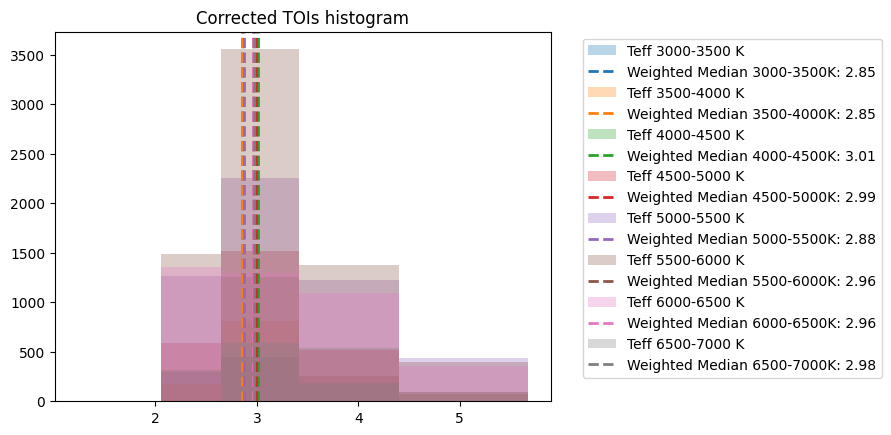

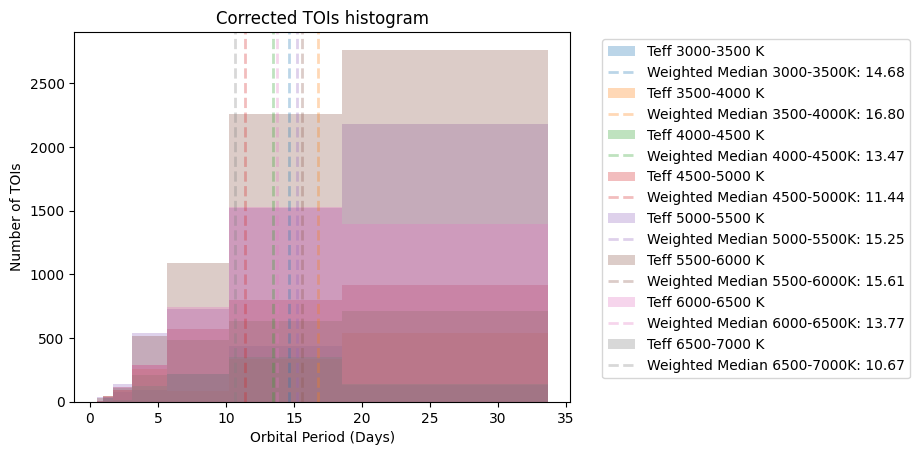

Rows with any NaNs in merged_df: 0
Rows with NaNs in merged_df:
Empty DataFrame
Columns: [toi, st_teff, pl_rade, pl_orbper, teff_bin, radius_bin_min, radius_bin_max, period_bin_min, period_bin_max, True Radius (Earth Radii), True Period (Days), detections, trials, transit_prob, detection_rate, radius_bin, period_bin, detection_inverse, transit_inverse, weight]
Index: []


In [ ]:
 
TOIs = pd.read_csv('../TOI_Mar2025_0to6_R.csv')

# Define temperature ranges matching our completeness data
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), 
               (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]

#teff_ranges = [(t, t + 1000) for t in range(3000, 7000, 1000)]

# Filter TOIs data
TOIs_filtered = TOIs.dropna(subset=['st_teff', 'pl_rade'])
TOIs_filtered = TOIs_filtered[(TOIs_filtered['pl_rade'] > 2.5) & (TOIs_filtered['pl_rade'] < 5)]
TOIs_filtered = TOIs_filtered[(TOIs_filtered['pl_orbper'] > 0.519) & (TOIs_filtered['pl_orbper'] < 30)]
#TOIs_filtered = TOIs_filtered[~TOIs_filtered['id'].isin([80224448, 370009806])] # The ones with giant corrections
#TOIs_filtered = TOIs_filtered[(TOIs_filtered['ruwe'] <= 1.4)]

# Remove false positives if column exists
if 'tfopwg_disp' in TOIs_filtered.columns:
    TOIs_filtered = TOIs_filtered[TOIs_filtered['tfopwg_disp'] != 'FP']

TOIs_filtered = TOIs_filtered[['toi', 'st_teff', 'pl_rade', 'pl_orbper']]

radius_bins = [(radius_bin_edges[i], radius_bin_edges[i+1]) for i in range(len(radius_bin_edges)-1)]

period_bins = [(period_bin_edges[i], period_bin_edges[i+1]) for i in range(len(period_bin_edges)-1)]
#print(TOIs_filtered)

#print(radius_bins)
#print(period_bins)

for row in TOIs_filtered.itertuples():
    teff = row.st_teff
    radius = row.pl_rade
    period = row.pl_orbper
    
    # Determine which temperature bin the TOI falls into
    for teff_min, teff_max in teff_ranges:
        if teff_min <= teff < teff_max:
            teff_bin = f"{teff_min}_{teff_max}"
            TOIs_filtered.at[row.Index, 'teff_bin'] = teff_bin
    
    for rad_min, rad_max in radius_bins:
        if rad_min <= radius < rad_max:
            radius_bin_min = rad_min
            radius_bin_max = rad_max
            TOIs_filtered.at[row.Index, 'radius_bin_min'] = radius_bin_min
            TOIs_filtered.at[row.Index, 'radius_bin_max'] = radius_bin_max

    for per_min, per_max in period_bins:
        if per_min <= period < per_max:
            period_bin_min = per_min
            period_bin_max = per_max
            TOIs_filtered.at[row.Index, 'period_bin_min'] = period_bin_min
            TOIs_filtered.at[row.Index, 'period_bin_max'] = period_bin_max

#print(TOIs_filtered)
  
# Merge TOIs with completeness data
merged_df = pd.merge(TOIs_filtered, df, on=['teff_bin', 'radius_bin_min', 'radius_bin_max', 'period_bin_min', 'period_bin_max'], how='left')
#print(merged_df)

#### REGULAR HISTOGRAM
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_rade'], bins=radius_bin_edges, alpha=.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K')
    hist_color = patches[0].get_facecolor()
    median_val = teff_df['pl_rade'].median()
    plt.axvline(median_val, linestyle='--', linewidth=2, color=hist_color, label=f'Median {temp_range[0]}-{temp_range[1]}K: {median_val:.2f}', alpha=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Planet Radius (Earth Radii)')
    plt.ylabel('Number of TOIs')
    plt.title('Normal TOIs histogram')
plt.show()

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_orbper'], bins=period_bin_edges, alpha=0.3, label=f'Teff {temp_range[0]}-{temp_range[1]} K')
    hist_color = patches[0].get_facecolor()
    median_val = teff_df['pl_orbper'].median()
    plt.axvline(median_val, linestyle='--', linewidth=2, color=hist_color, label=f'Median {temp_range[0]}-{temp_range[1]}K: {median_val:.2f}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Orbital Period (Days)')
    plt.ylabel('Number of TOIs')
    plt.title('Normal TOIs histogram')
plt.show()
########

# calculate inverse detection and transit probabilities
for row in merged_df.itertuples():
    detection_rate = row.detection_rate
    transit_prob = row.transit_prob

    # Only update detection_inverse and transit_inverse, leave other columns untouched
    if pd.notnull(detection_rate) and detection_rate > 0:
        merged_df.at[row.Index, 'detection_inverse'] = 1/detection_rate
    else:
        merged_df.at[row.Index, 'detection_inverse'] = np.nan

    if pd.notnull(transit_prob) and transit_prob > 0:
        merged_df.at[row.Index, 'transit_inverse'] = 1/transit_prob
    else:
        merged_df.at[row.Index, 'transit_inverse'] = np.nan
#print(merged_df)

#merged_df to csv
#merged_df[['toi', 'detection_inverse', 'transit_inverse']].to_csv('merged_df.csv', index=False)

# Duplicate each row of merged_df according to a per-row count value in a new column 'row_count'
# First, define how you want to calculate 'weight' for each row. 
# Example: here we use detection_inverse * transit_inverse rounded to nearest int, but you can change this logic.
merged_df['weight'] = (merged_df['detection_inverse'] * merged_df['transit_inverse']).fillna(1)
#merged_df['mult_count'] = np.where(merged_df['mult_count'] >= 1, merged_df['mult_count'] - 1, merged_df['mult_count'])
#print(merged_df[['toi', 'detection_rate', 'transit_prob', 'detection_inverse', 'transit_inverse', 'mult_count']])

#print(merged_df)
#print(merged_df[['toi', 'detection_inverse', 'transit_inverse', 'row_count']])
# Now repeat each row according to its 'row_count' value
#merged_df_corrected = merged_df#.loc[merged_df.index.repeat(merged_df['mult_count'])].reset_index(drop=True)

radius_medians = pd.DataFrame(columns=['Teff Range', 'Weighted Median Radius (Earth Radii)'])
###CORRECTED HISTOGRAM
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_rade'], bins=radius_bin_edges, alpha=0.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K', weights=teff_df['weight'])
    hist_color = patches[0].get_facecolor()
    # Calculate weighted median
    vals = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
        radius_medians = pd.concat([
            radius_medians,
            pd.DataFrame({
            'Teff Range': [f"{temp_range[0]}-{temp_range[1]}K"],
            'Weighted Median Radius (Earth Radii)': [weighted_median]
            })], ignore_index=True)
        plt.axvline(weighted_median, linestyle='--', linewidth=2, color=hist_color, label=f'Weighted Median {temp_range[0]}-{temp_range[1]}K: {weighted_median:.2f}', alpha=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Corrected TOIs histogram')
plt.show()

#radius_medians.to_csv('corrected_medians.csv', index=False)

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_orbper'], bins=period_bin_edges, alpha=0.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K', weights=teff_df['weight'])
    hist_color = patches[0].get_facecolor()
    # Calculate weighted median
    vals = teff_df['pl_orbper'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
        plt.axvline(weighted_median, linestyle='--', linewidth=2, color=hist_color, label=f'Weighted Median {temp_range[0]}-{temp_range[1]}K: {weighted_median:.2f}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Orbital Period (Days)')
    plt.ylabel('Number of TOIs')
    plt.title('Corrected TOIs histogram')
plt.show()
#######

#print how many rows have NaNs in merged_df
print("Rows with any NaNs in merged_df:", merged_df.isnull().any(axis=1).sum())
print("Rows with NaNs in merged_df:")
print(merged_df[merged_df.isnull().any(axis=1)])

toi                  122.01     175.02    206.01     210.01     218.02   \
radius_bin_center                                                         
1.400000            0.000000   0.000000  8.562633   0.000000   0.000000   
1.808049            0.000000   0.000000  0.000000   0.000000  66.087102   
2.330118           24.750168   0.000000  0.000000  47.869871   0.000000   
3.003361            0.000000  37.204463  0.000000   0.000000   0.000000   
3.876490            0.000000   0.000000  0.000000   0.000000   0.000000   

toi                  237.01      256.01     256.02      406.01     454.01   \
radius_bin_center                                                            
1.400000            0.000000    0.000000  44.858622    0.000000   0.000000   
1.808049           33.697729  268.195911   0.000000  135.197553   0.000000   
2.330118            0.000000    0.000000   0.000000    0.000000   0.000000   
3.003361            0.000000    0.000000   0.000000    0.000000   0.000000   
3.8764

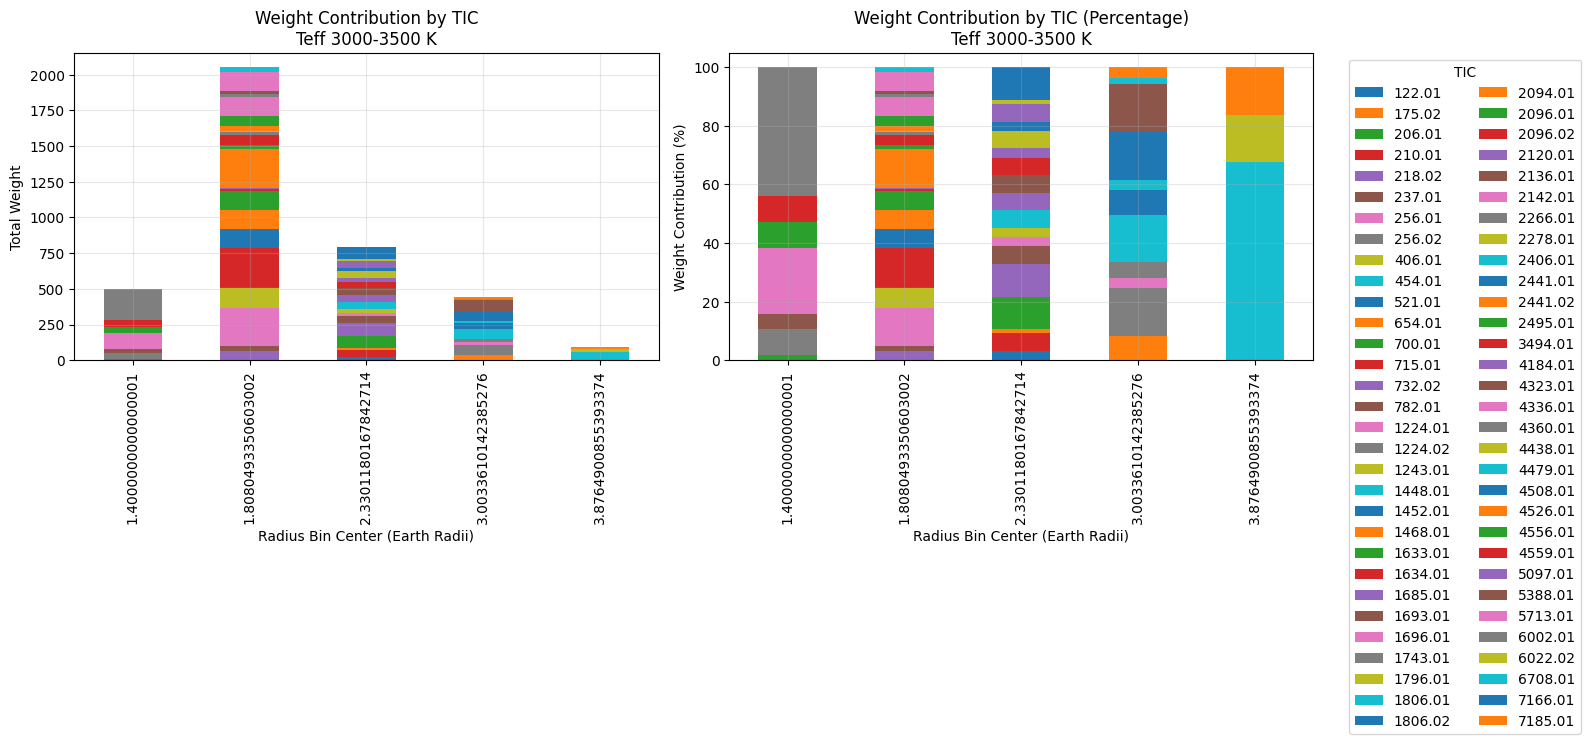


=== Teff 3000-3500 K ===
Total unique TICs: 62
Average weight per radius bin: 776.20

Top 5 TICs by total weight contribution:
  TIC 2094.01: 268.20 (6.9%)
  TIC 256.01: 268.20 (6.9%)
  TIC 715.01: 268.20 (6.9%)
  TIC 6002.01: 218.45 (5.6%)
  TIC 4336.01: 135.20 (3.5%)
toi                  177.01      233.01     233.02     269.01    270.01   \
radius_bin_center                                                          
1.400000            0.000000    0.000000   0.000000   0.000000   0.00000   
1.808049           16.152288  148.945328  58.888235   0.000000   0.00000   
2.330118            0.000000    0.000000   0.000000   0.000000  36.09509   
3.003361            0.000000    0.000000   0.000000  18.081321   0.00000   
3.876490            0.000000    0.000000   0.000000   0.000000   0.00000   

toi                  270.02     557.01     620.01     663.01     663.02   ...  \
radius_bin_center                                                         ...   
1.400000            0.000000   0.0

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_12384/15629100.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


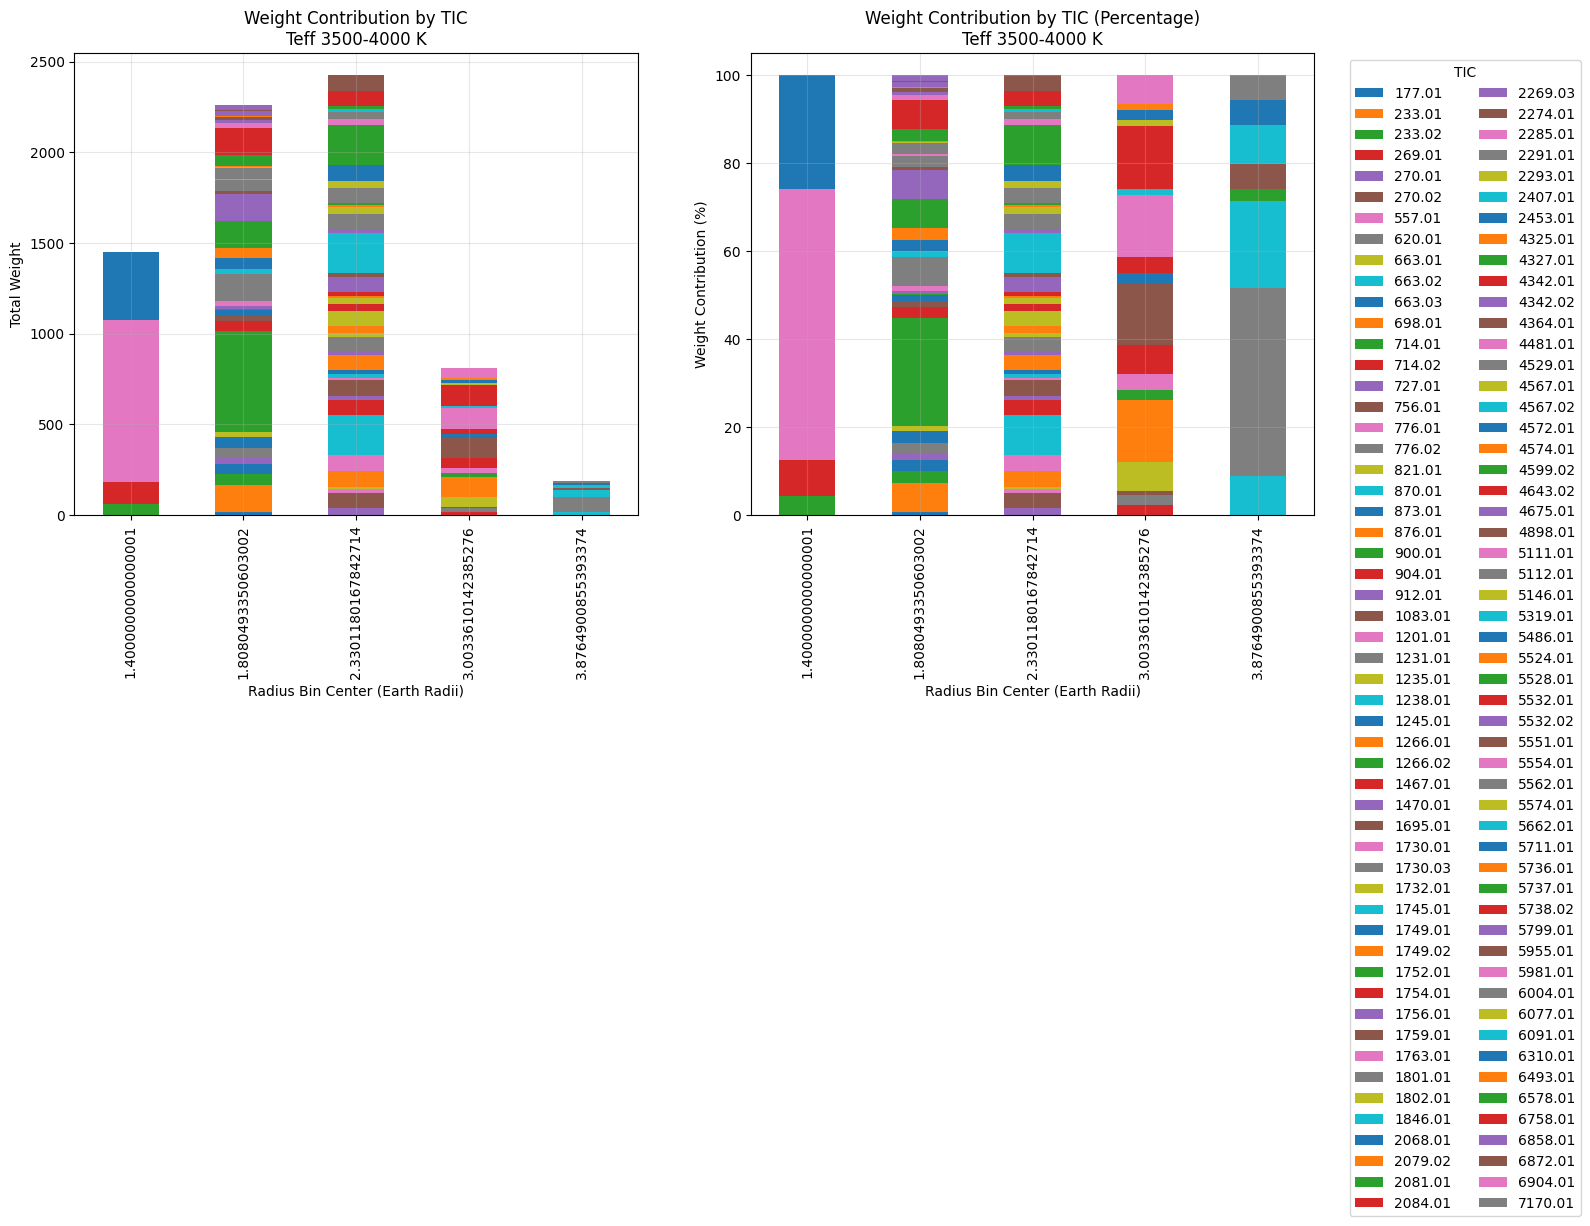


=== Teff 3500-4000 K ===
Total unique TICs: 108
Average weight per radius bin: 1426.44

Top 5 TICs by total weight contribution:
  TIC 2285.01: 892.42 (12.5%)
  TIC 1266.02: 554.00 (7.8%)
  TIC 4572.01: 374.89 (5.3%)
  TIC 4567.02: 219.72 (3.1%)
  TIC 870.01: 219.72 (3.1%)
toi                 133.01     139.01     178.01     178.02     178.03   \
radius_bin_center                                                         
1.400000            0.00000   0.000000   0.000000   0.000000   0.000000   
1.808049           60.74282   0.000000   0.000000   0.000000   0.000000   
2.330118            0.00000  58.926088  29.474042   0.000000  29.474042   
3.003361            0.00000   0.000000   0.000000   0.000000   0.000000   
3.876490            0.00000   0.000000   0.000000  76.461241   0.000000   

toi                  178.04     240.01     249.01      260.01      279.01   \
radius_bin_center                                                            
1.400000           43.089241   0.000000   0

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_12384/15629100.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


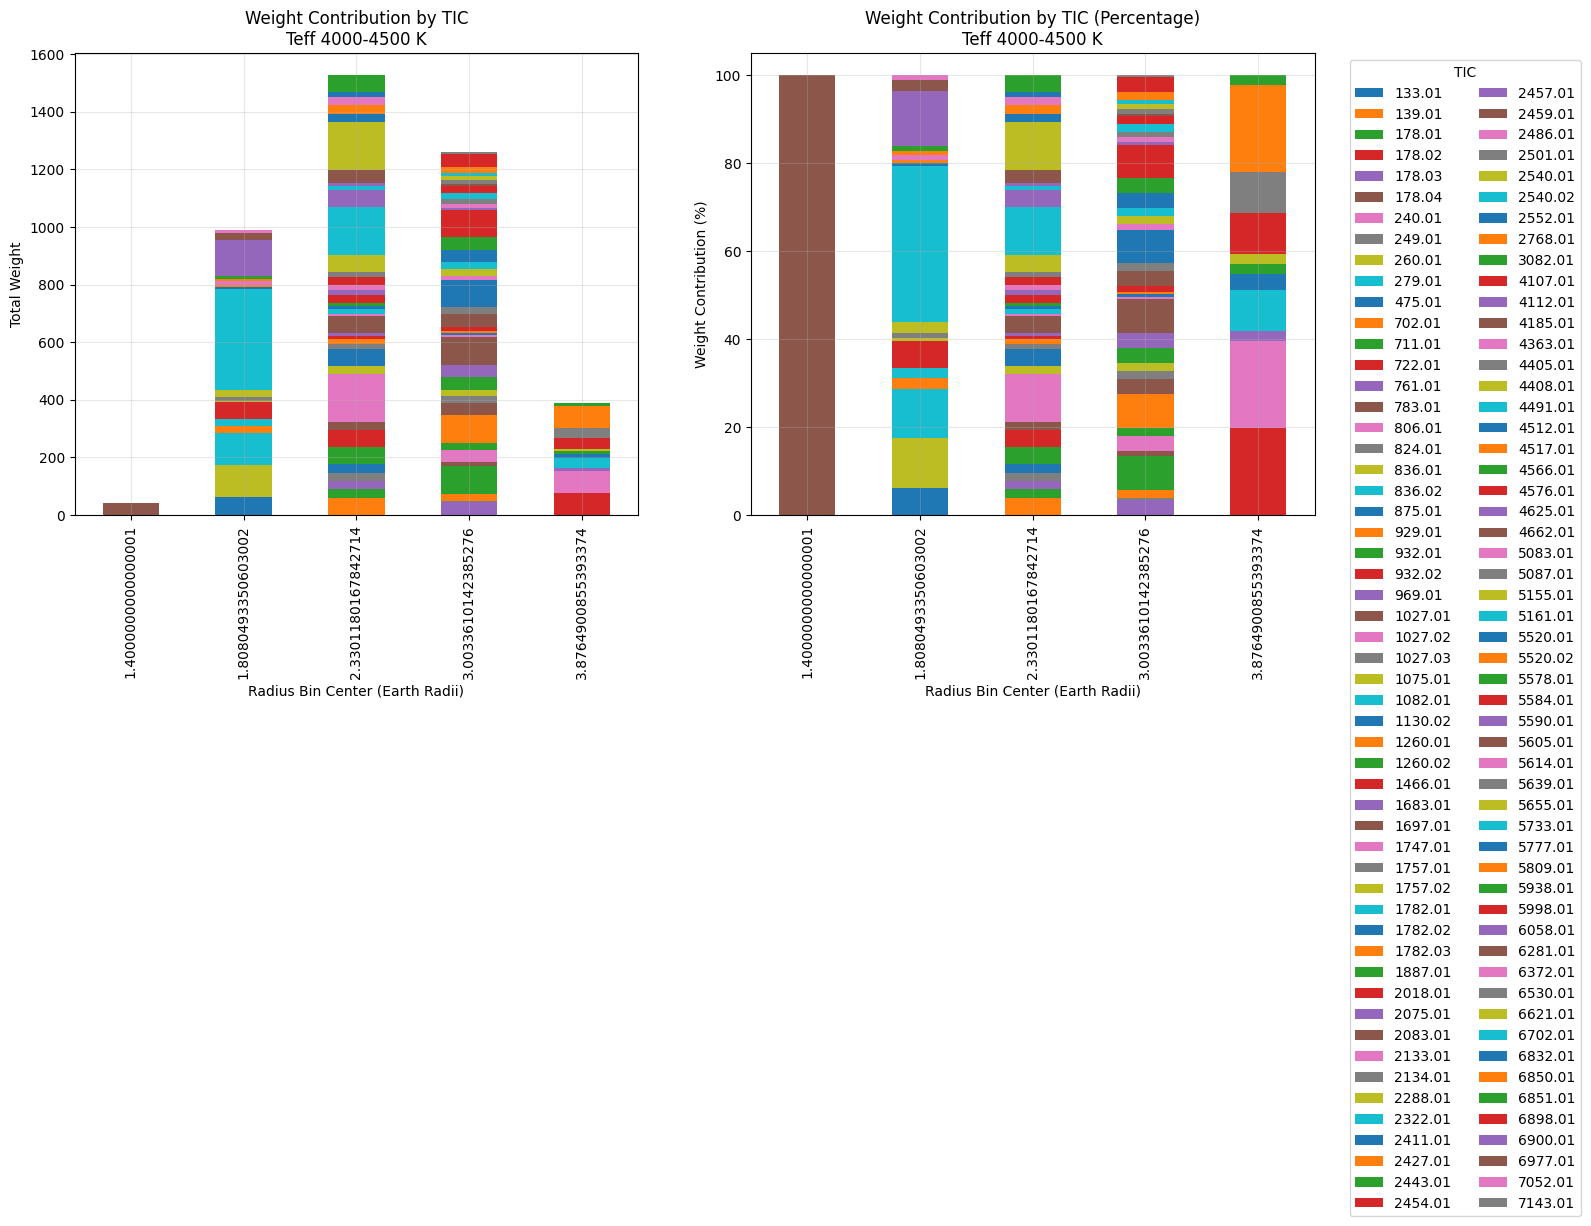


=== Teff 4000-4500 K ===
Total unique TICs: 108
Average weight per radius bin: 841.59

Top 5 TICs by total weight contribution:
  TIC 2322.01: 352.95 (8.4%)
  TIC 806.01: 165.03 (3.9%)
  TIC 5655.01: 165.03 (3.9%)
  TIC 2540.02: 165.03 (3.9%)
  TIC 6900.01: 111.64 (2.7%)
toi                  137.01    168.01      174.01      174.02     209.01   \
radius_bin_center                                                           
1.400000            0.000000  0.000000    0.000000    0.000000   0.000000   
1.808049           28.261523  0.000000  159.523961  395.566276   0.000000   
2.330118            0.000000  0.000000    0.000000    0.000000  18.606706   
3.003361            0.000000  9.368741    0.000000    0.000000   0.000000   
3.876490            0.000000  0.000000    0.000000    0.000000   0.000000   

toi                   213.01     314.01     431.01      461.01    494.01   \
radius_bin_center                                                           
1.400000             0.000000   0

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_12384/15629100.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


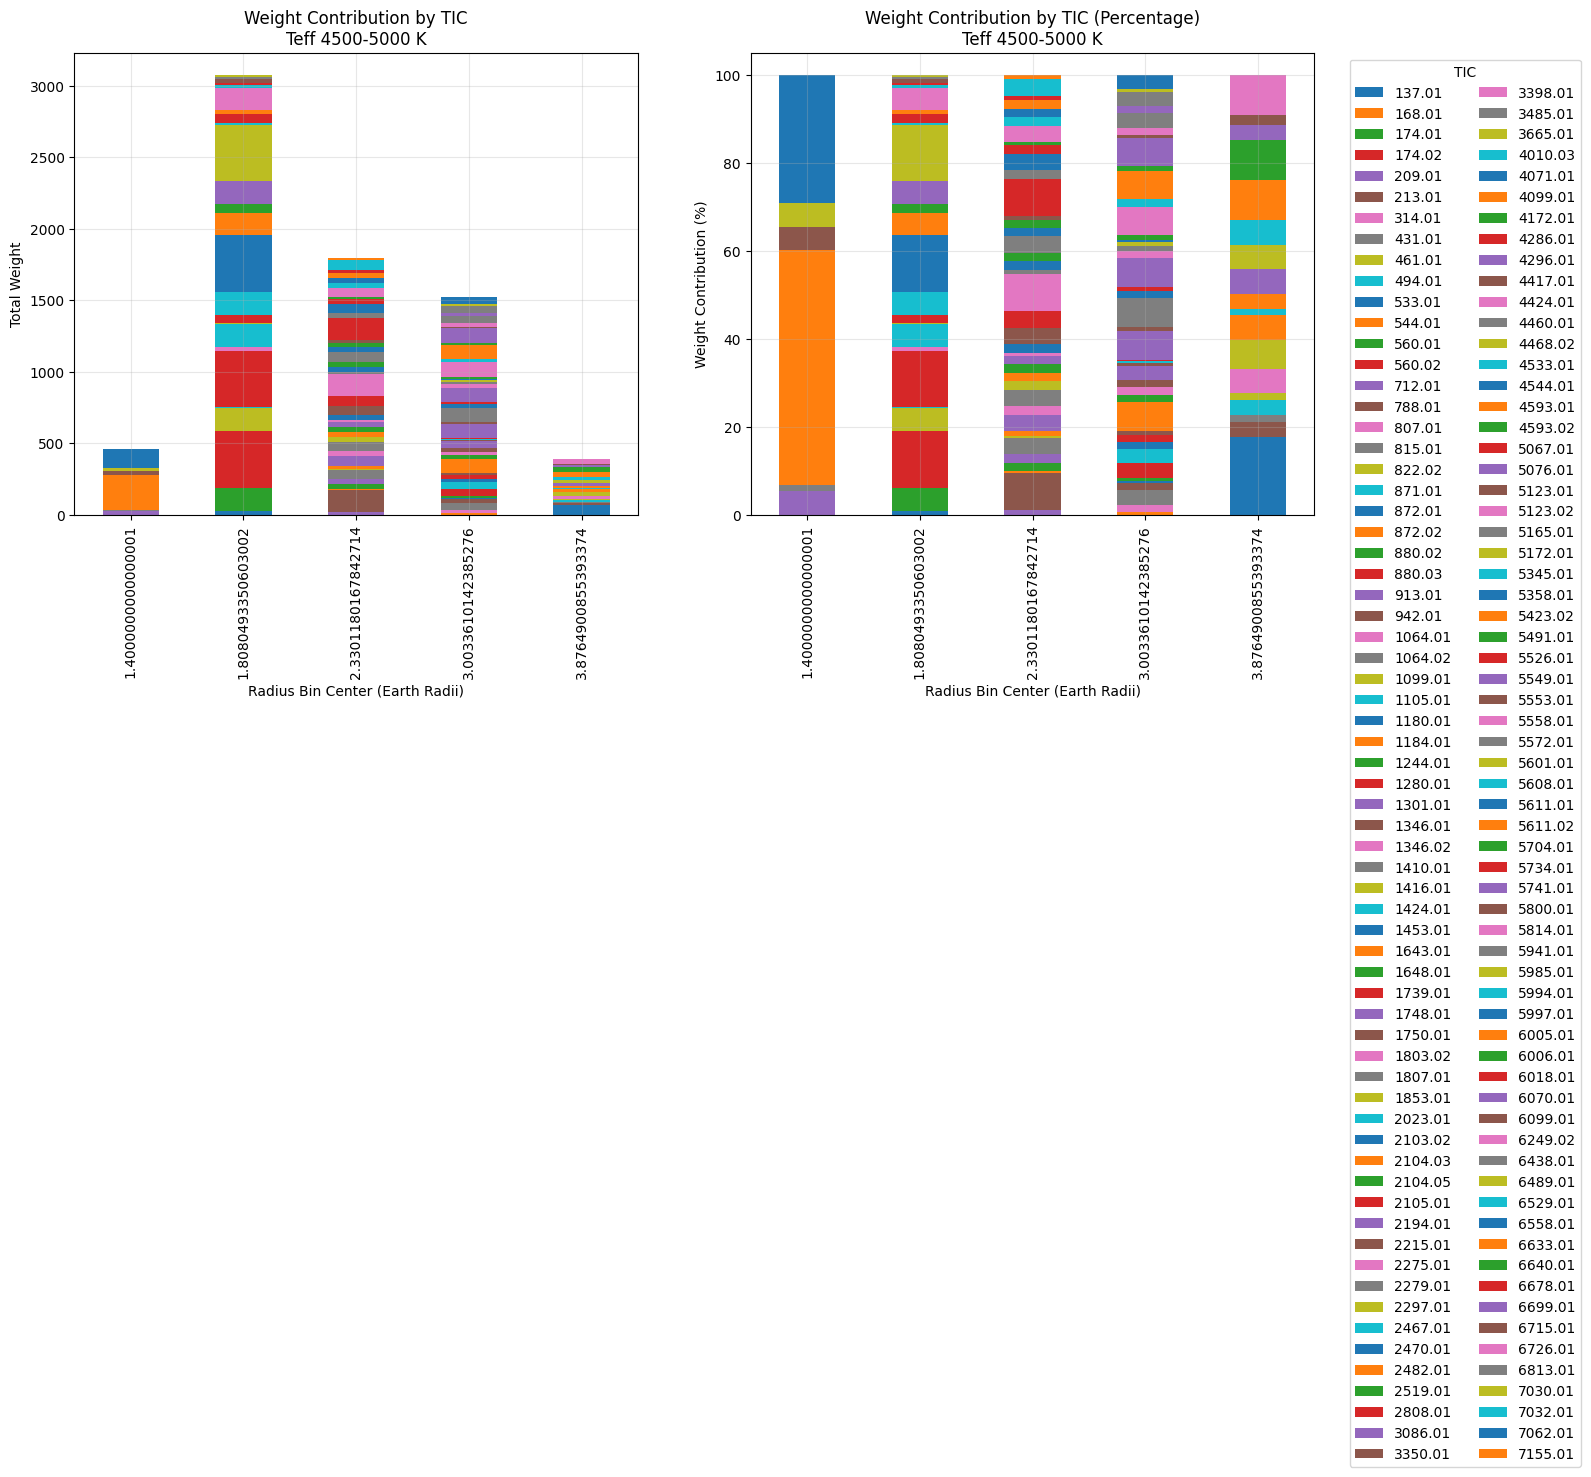


=== Teff 4500-5000 K ===
Total unique TICs: 132
Average weight per radius bin: 1450.84

Top 5 TICs by total weight contribution:
  TIC 2103.02: 395.57 (5.5%)
  TIC 174.02: 395.57 (5.5%)
  TIC 2297.01: 395.57 (5.5%)
  TIC 560.02: 395.57 (5.5%)
  TIC 2482.01: 246.59 (3.4%)
toi                  119.01      119.02    125.01    125.02      125.03   \
radius_bin_center                                                          
1.400000            0.000000    0.000000   0.00000   0.00000    0.000000   
1.808049           25.425498  232.797527   0.00000   0.00000    0.000000   
2.330118            0.000000    0.000000   0.00000  31.69714  261.300259   
3.003361            0.000000    0.000000  14.45983   0.00000    0.000000   
3.876490            0.000000    0.000000   0.00000   0.00000    0.000000   

toi                 179.01      208.01      214.01     220.01     223.01   \
radius_bin_center                                                           
1.400000            0.00000    0.000000 

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_12384/15629100.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


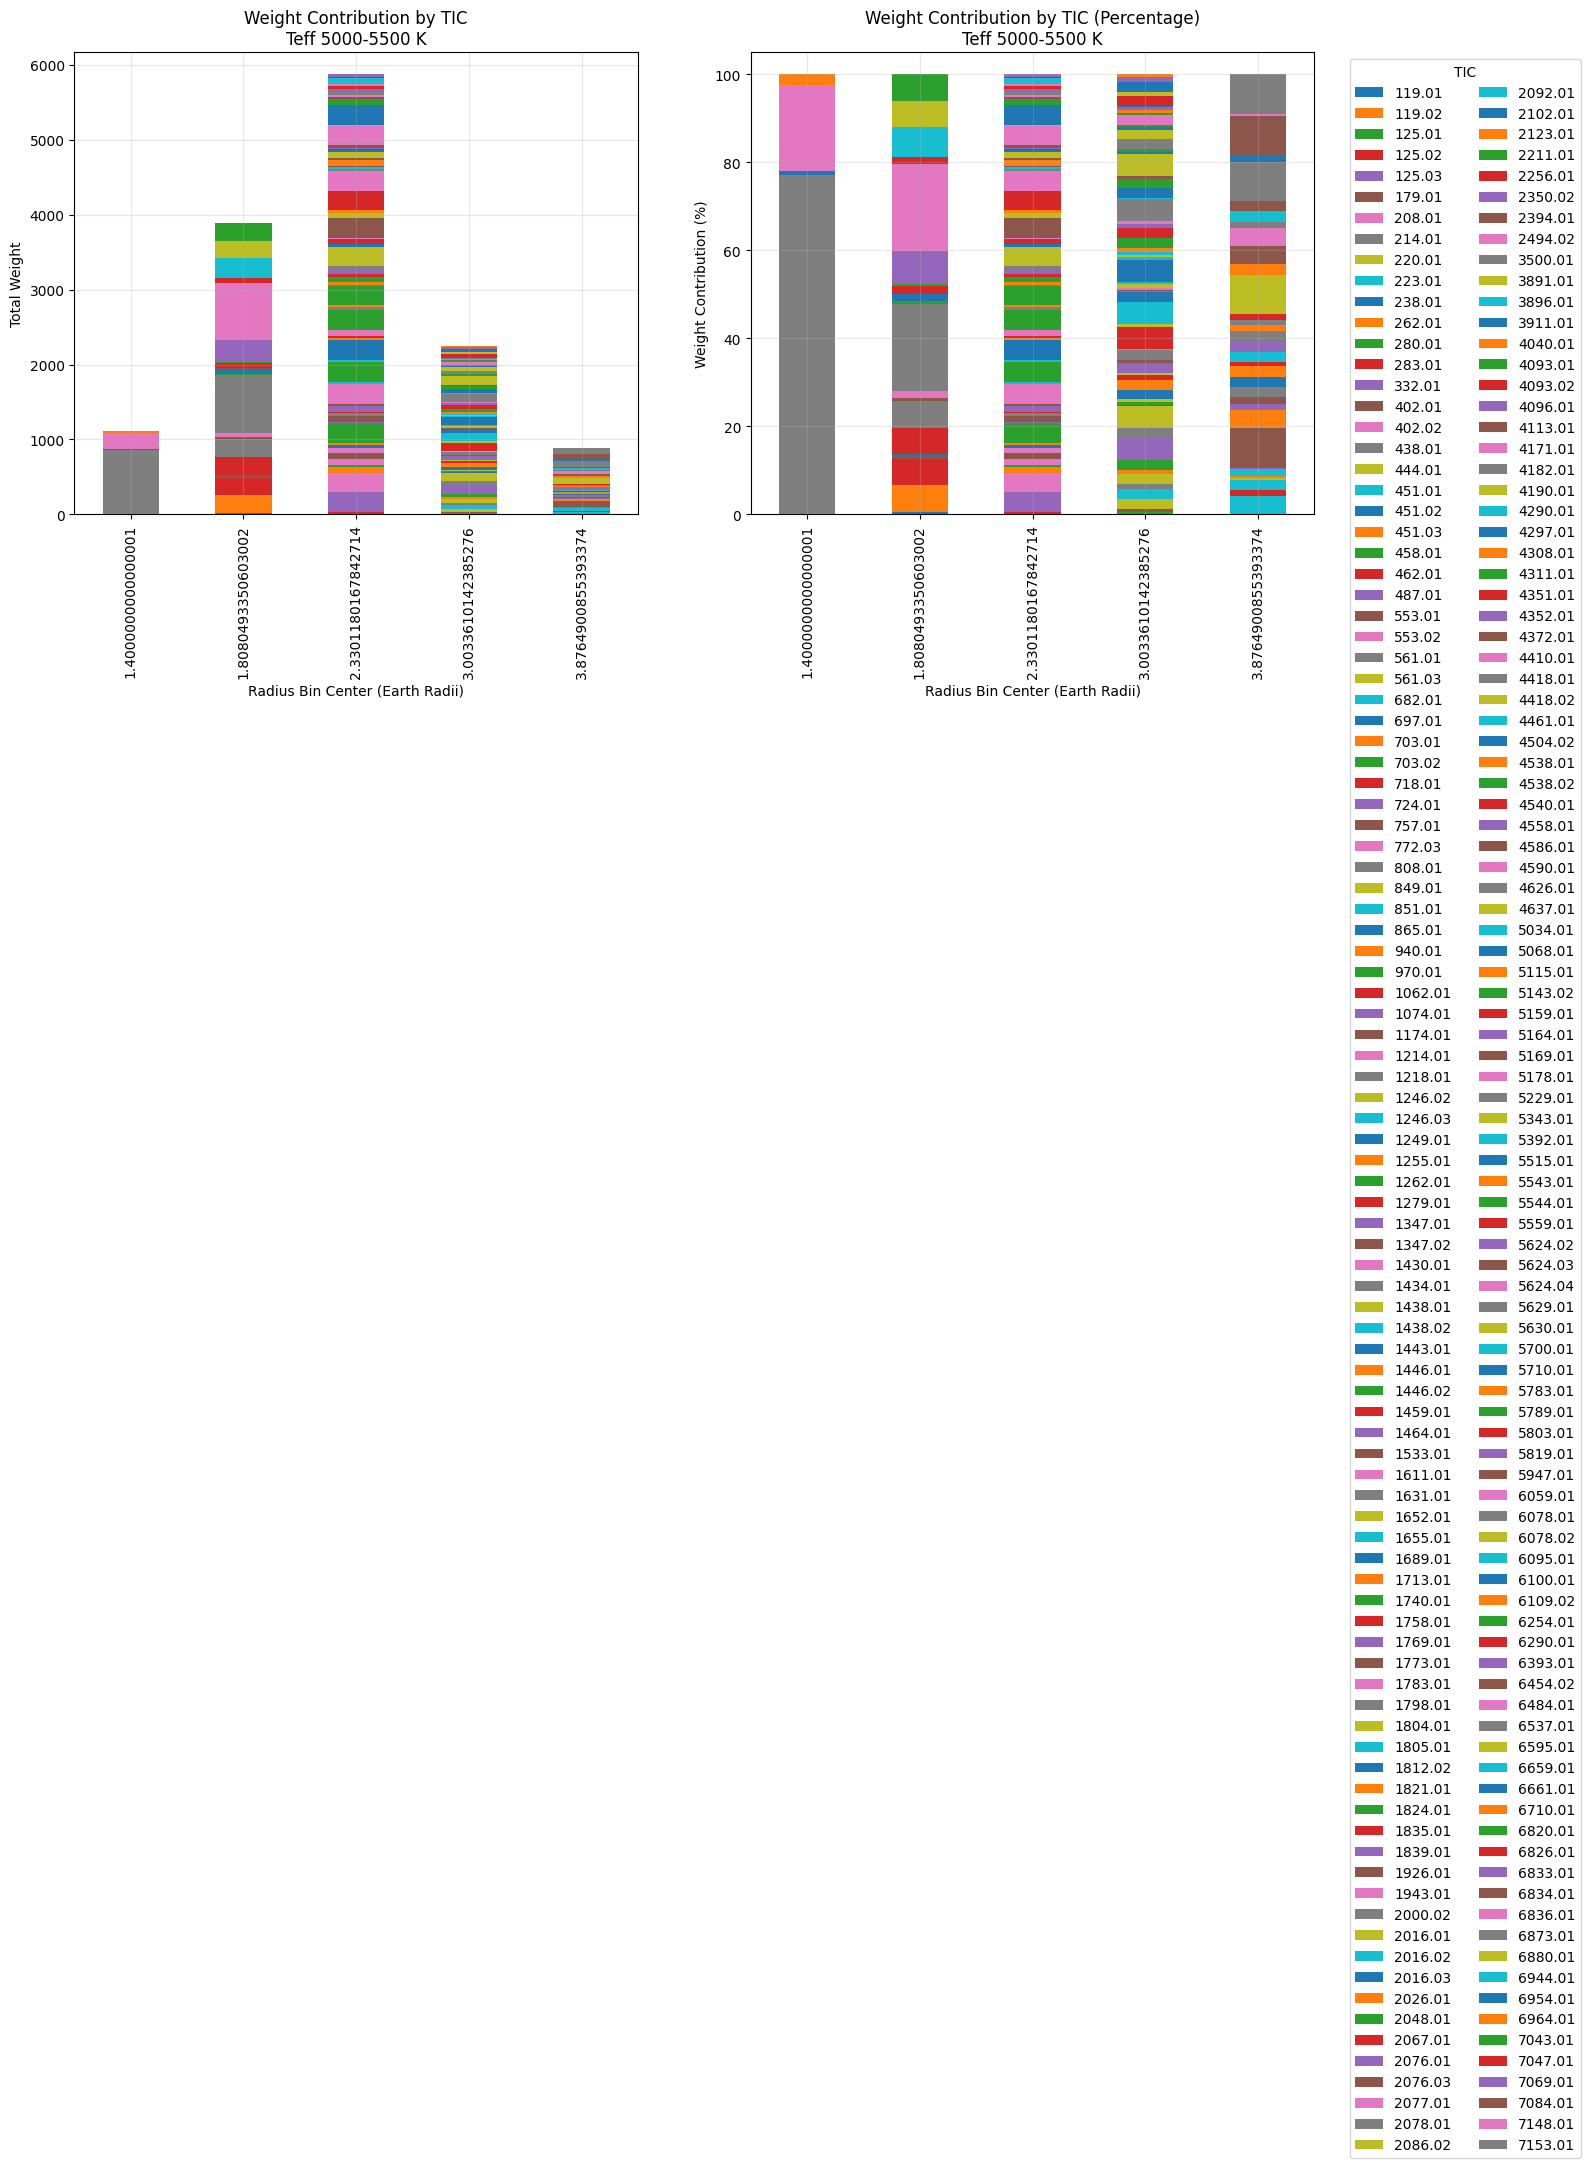


=== Teff 5000-5500 K ===
Total unique TICs: 198
Average weight per radius bin: 2801.23

Top 5 TICs by total weight contribution:
  TIC 214.01: 857.35 (6.1%)
  TIC 1434.01: 761.98 (5.4%)
  TIC 4590.01: 761.98 (5.4%)
  TIC 1824.01: 261.30 (1.9%)
  TIC 4410.01: 261.30 (1.9%)
toi                 132.01    141.01    144.01      215.01     248.01   \
radius_bin_center                                                        
1.400000           0.000000  0.000000   0.00000    0.000000   0.000000   
1.808049           0.000000  7.190485  72.49647    0.000000   0.000000   
2.330118           0.000000  0.000000   0.00000    0.000000  33.364177   
3.003361           0.000000  0.000000   0.00000  114.908275   0.000000   
3.876490           7.334487  0.000000   0.00000    0.000000   0.000000   

toi                  251.01     261.01     261.02     266.01    266.02   ...  \
radius_bin_center                                                        ...   
1.400000            0.000000   0.000000   0.000

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_12384/15629100.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


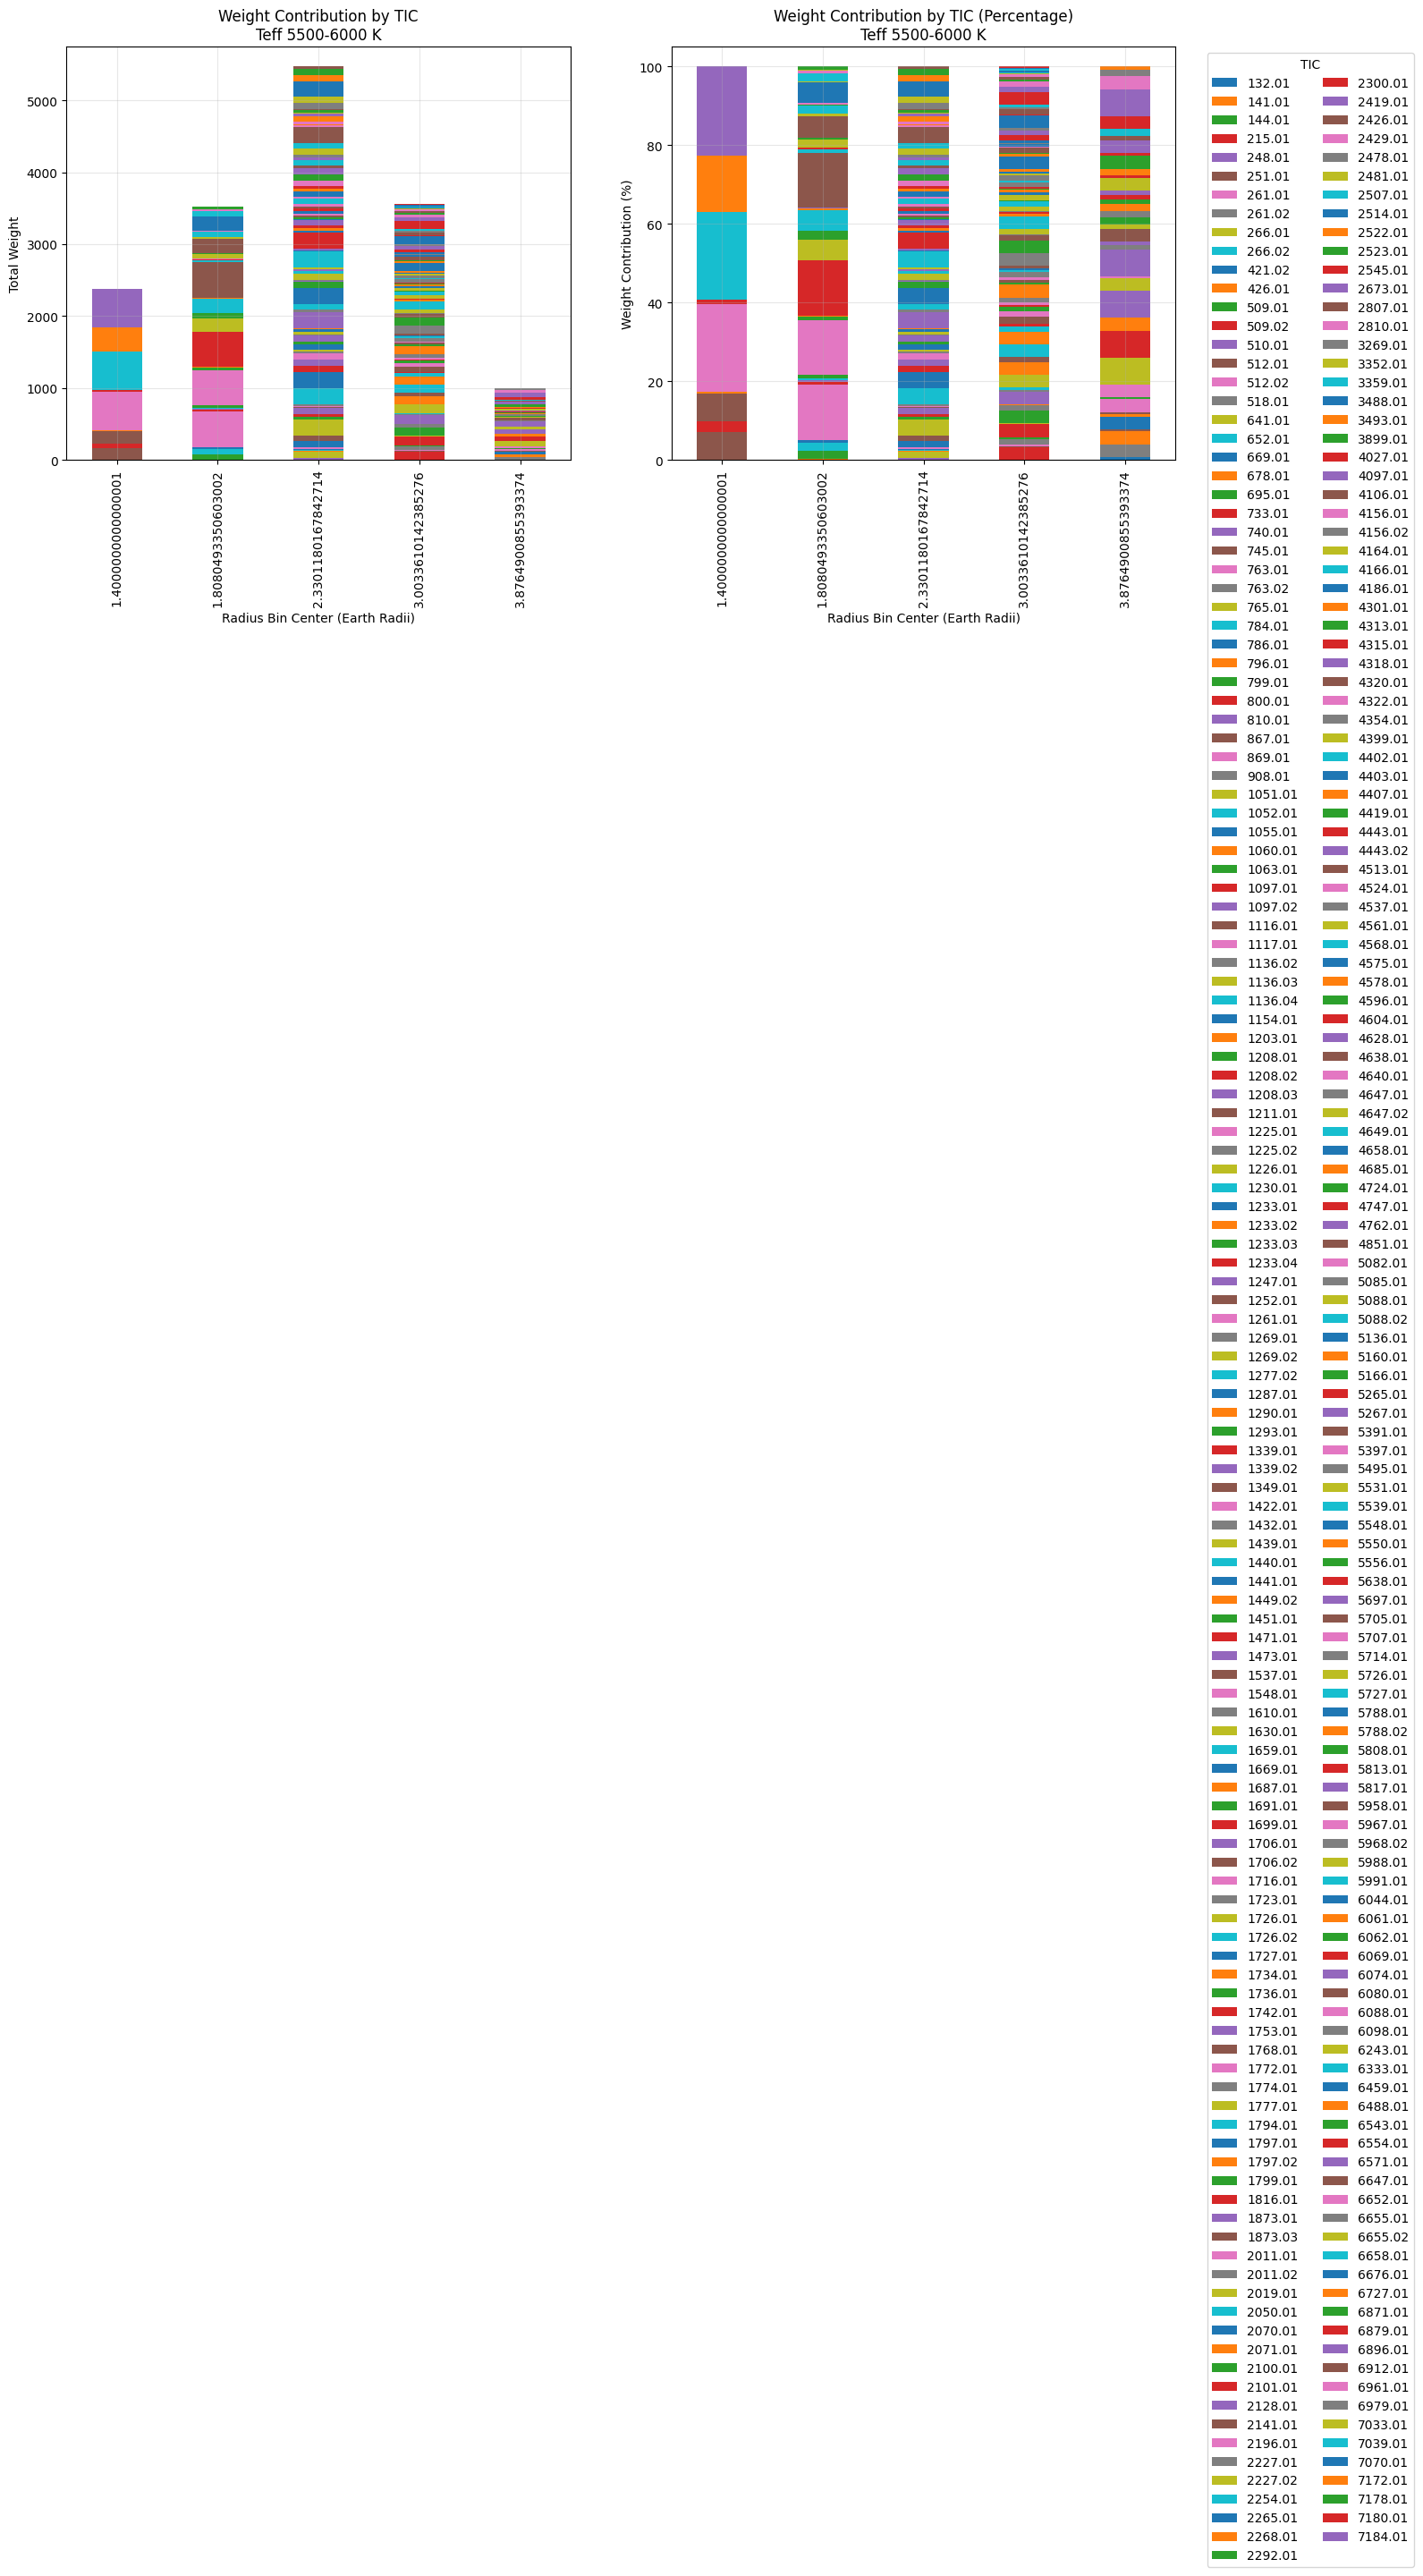


=== Teff 5500-6000 K ===
Total unique TICs: 265
Average weight per radius bin: 3186.64

Top 5 TICs by total weight contribution:
  TIC 6074.01: 530.38 (3.3%)
  TIC 2011.01: 530.38 (3.3%)
  TIC 5088.02: 530.38 (3.3%)
  TIC 4320.01: 491.46 (3.1%)
  TIC 512.02: 491.46 (3.1%)
toi                  128.01      130.01    173.02    188.01     205.01   \
radius_bin_center                                                         
1.400000            0.000000    0.000000   0.00000  0.000000   0.000000   
1.808049            0.000000    0.000000   0.00000  0.000000   0.000000   
2.330118           17.791605  119.723357  37.25424  0.000000  17.791605   
3.003361            0.000000    0.000000   0.00000  0.000000   0.000000   
3.876490            0.000000    0.000000   0.00000  4.167199   0.000000   

toi                  230.01      254.01    271.01      282.04    396.01   ...  \
radius_bin_center                                                         ...   
1.400000            0.000000    0.0000

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_12384/15629100.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


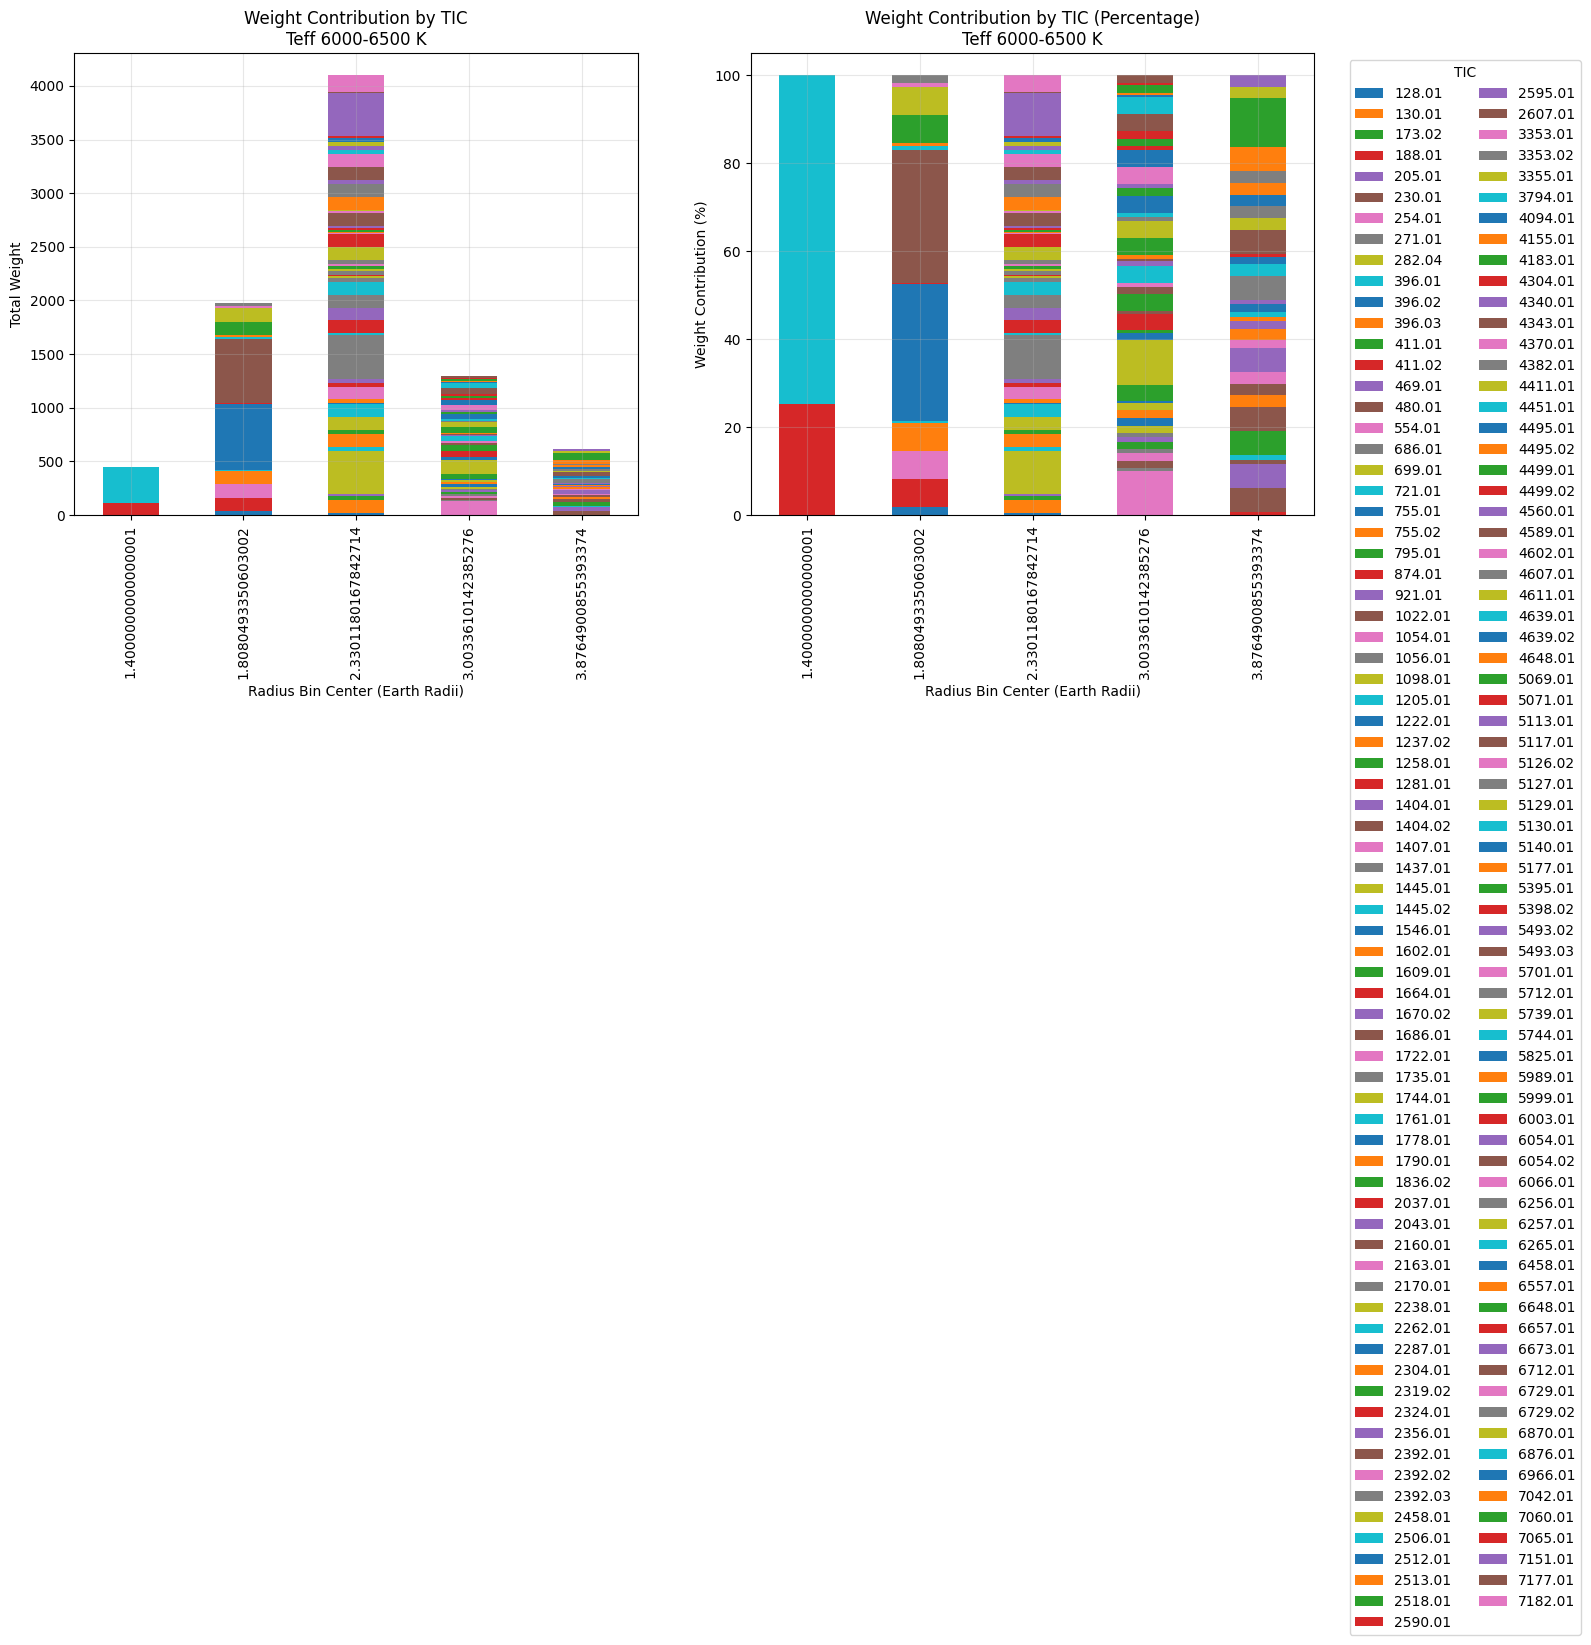


=== Teff 6000-6500 K ===
Total unique TICs: 147
Average weight per radius bin: 1688.33

Top 5 TICs by total weight contribution:
  TIC 2287.01: 600.81 (7.1%)
  TIC 4343.01: 600.81 (7.1%)
  TIC 6673.01: 404.83 (4.8%)
  TIC 1437.01: 404.83 (4.8%)
  TIC 282.04: 404.83 (4.8%)
toi                  787.01     896.01     1204.01    1219.01   1250.01  \
radius_bin_center                                                         
1.400000           27.998548   0.000000   0.000000   0.000000  0.000000   
1.808049            0.000000   0.000000  10.239339  20.948492  0.000000   
2.330118            0.000000   0.000000   0.000000   0.000000  0.000000   
3.003361            0.000000  13.756213   0.000000   0.000000  0.000000   
3.876490            0.000000   0.000000   0.000000   0.000000  3.709458   

toi                 1447.01   1620.01    1737.01    1819.01    2056.01  ...  \
radius_bin_center                                                       ...   
1.400000           0.000000  0.000000   0.

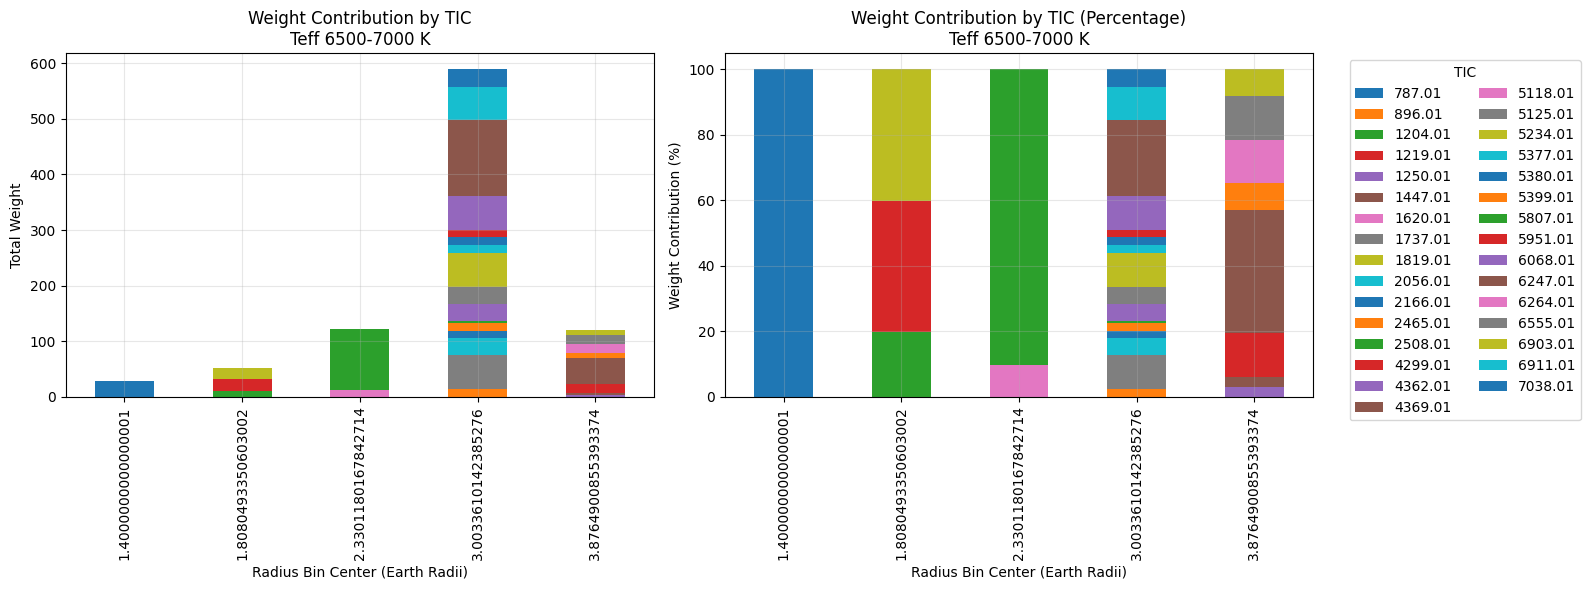


=== Teff 6500-7000 K ===
Total unique TICs: 31
Average weight per radius bin: 182.24

Top 5 TICs by total weight contribution:
  TIC 6247.01: 135.91 (14.9%)
  TIC 5807.01: 110.05 (12.1%)
  TIC 6911.01: 60.90 (6.7%)
  TIC 6068.01: 60.90 (6.7%)
  TIC 5234.01: 60.90 (6.7%)


In [16]:
#for each radius, I want to know the weight contribution of each tic in a stacked histogram, with percentages

# For each radius bin, show weight contribution of each TIC in a stacked histogram with percentages
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])].copy()
    
    if len(teff_df) == 0:
        continue
    
    # Add radius bin center for grouping
    # Calculate radius bin center in log space
    teff_df['radius_bin_center'] = 10 ** ((np.log10(teff_df['radius_bin_min']) + np.log10(teff_df['radius_bin_max'])) / 2)
    #how does it get the right bins from just the center
    # Create pivot table: rows=radius bins, columns=TICs, values=sum of weights
    pivot = teff_df.pivot_table(
        index='radius_bin_center',
        columns='toi',
        values='weight',
        aggfunc='sum',
        fill_value=0
    )
    print(pivot)
    # Calculate percentage contribution per radius bin
    pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Absolute weights
    pivot.plot(kind='bar', stacked=True, ax=ax1, legend=False)
    ax1.set_xlabel('Radius Bin Center (Earth Radii)')
    ax1.set_ylabel('Total Weight')
    ax1.set_title(f'Weight Contribution by TIC\nTeff {temp_range[0]}-{temp_range[1]} K')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Percentage weights
    pivot_percent.plot(kind='bar', stacked=True, ax=ax2)
    ax2.set_xlabel('Radius Bin Center (Earth Radii)')
    ax2.set_ylabel('Weight Contribution (%)')
    ax2.set_title(f'Weight Contribution by TIC (Percentage)\nTeff {temp_range[0]}-{temp_range[1]} K')
    ax2.grid(True, alpha=0.3)
    ax2.legend(title='TIC', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== Teff {temp_range[0]}-{temp_range[1]} K ===")
    print(f"Total unique TICs: {len(pivot.columns)}")
    print(f"Average weight per radius bin: {pivot.sum(axis=1).mean():.2f}")
    print("\nTop 5 TICs by total weight contribution:")
    top_tics = pivot.sum(axis=0).sort_values(ascending=False).head(5)
    for tic, weight in top_tics.items():
        print(f"  TIC {tic}: {weight:.2f} ({weight/pivot.sum().sum()*100:.1f}%)")

   Teff Range  Weighted Median Radius (Earth Radii)
0  3000-3500K                              1.916028
1  3500-4000K                              2.020550
2  4000-4500K                              2.381203
3  4500-5000K                              2.143860
4  5000-5500K                              2.358480
5  5500-6000K                              2.288171
6  6000-6500K                              2.374140
7  6500-7000K                              2.797790


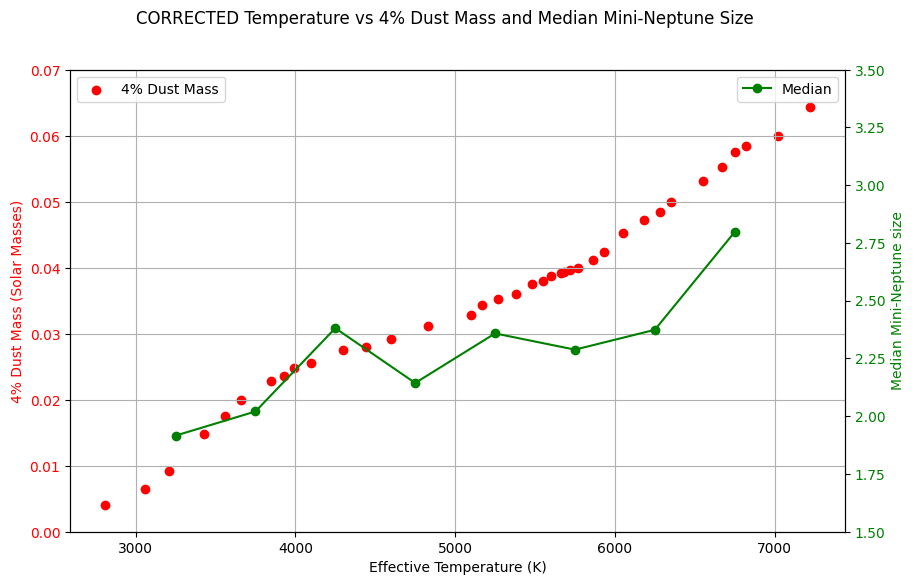

In [17]:
data = {
    'Stellar Type': ['M0V', 'M1V', 'M2V', 'M3V', 'M4V', 'M5V', 'M6V', 'K0V', 'K1V', 'K2V', 'K3V', 'K4V', 'K5V', 'K6V', 'K7V', 'K8V', 'K9V',
                     'G0V', 'G1V', 'G2V', 'G3V', 'G4V', 'G5V', 'G6V', 'G7V', 'G8V', 'G9V',
                     'F0V', 'F1V', 'F2V', 'F3V', 'F4V', 'F5V', 'F6V', 'F7V', 'F8V', 'F9V'],
    'Mass': [0.57, 0.50, 0.44, 0.37, 0.23, 0.162, 0.102, 0.88, 0.86, 0.82, 0.78, 0.73, 0.70, 0.69, 0.64, 0.62, 0.59,
             1.06, 1.03, 1.00, 0.99, 0.985, 0.98, 0.97, 0.95, 0.94, 0.90,
             1.61, 1.50, 1.46, 1.44, 1.38, 1.33, 1.25, 1.21, 1.18, 1.13],
    'Radius': [0.588, 0.501, 0.446, 0.361, 0.274, 0.196, 0.137, 0.813, 0.797, 0.783, 0.755, 0.713, 0.701, 0.669, 0.630, 0.615, 0.608,
               1.100, 1.060, 1.012, 1.002, 0.991, 0.977, 0.949, 0.927, 0.914, 0.853,
               1.728, 1.679, 1.622, 1.578, 1.533, 1.473, 1.359, 1.324, 1.221, 1.167],
    'Luminosity': [0.069, 0.041, 0.029, 0.016, 7.2e-3, 3.0e-3, 1.0e-3, 0.46, 0.41, 0.37, 0.28, 0.20, 0.17, 0.14, 0.10, 0.087, 0.079,
                   1.35, 1.20, 1.02, 0.98, 0.91, 0.89, 0.79, 0.74, 0.68, 0.55,
                   7.24, 6.17, 5.13, 4.68, 4.17, 3.63, 2.69, 2.45, 1.95, 1.66],
    'Effective Temperature': [3850, 3660, 3560, 3430, 3210, 3060, 2810, 5270, 5170, 5100, 4830, 4600, 4440, 4300, 4100, 3990, 3930,
                              5930, 5860, 5770, 5720, 5680, 5660, 5600, 5550, 5480, 5380,
                              7220, 7020, 6820, 6750, 6670, 6550, 6350, 6280, 6180, 6050],
    'B-V Index': [1.42, 1.49, 1.51, 1.53, 1.65, 1.83, 2.01, 0.82, 0.86, 0.88, 0.99, 1.09, 1.15, 1.24, 1.34, 1.36, 1.40,
                  0.60, 0.62, 0.65, 0.66, 0.67, 0.68, 0.70, 0.71, 0.73, 0.78,
                  0.30, 0.33, 0.37, 0.39, 0.41, 0.44, 0.49, 0.50, 0.53, 0.56]
}
data['4% Dust Mass'] = [mass * 0.04 for mass in data['Mass']]
data['1/R^2'] = [1 / (radius ** 2) for radius in data['Radius']]

stellar_df = pd.DataFrame(data)
stellar_df = stellar_df.sort_values(by='Effective Temperature', ascending=True)

median_df = radius_medians
print(median_df)

median_df['Teff Range Average'] = median_df['Teff Range'].apply(
    lambda x: sum(map(int, x.replace('K', '').split('-'))) / 2
)

fig, ax1 = plt.subplots(figsize=(10, 6))

corrected_mean_median_df = median_df
# corrected_mean_median_df['Teff Range Average'] = corrected_mean_median_df['Teff Range'].apply(
#     lambda x: sum(map(int, x.replace('K', '').split('-'))) / 2
# )


# Plot 4% Dust Mass on the primary y-axis
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['4% Dust Mass'], color='r', label='4% Dust Mass')
ax1.set_xlabel('Effective Temperature (K)')
ax1.set_ylabel('4% Dust Mass (Solar Masses)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True)
ax1.set_ylim(-.00,.07)
#ax1.set_ylim(-.01,.0)

# Create a secondary y-axis for Median
ax2 = ax1.twinx()
ax2.plot(corrected_mean_median_df['Teff Range Average'], corrected_mean_median_df['Weighted Median Radius (Earth Radii)'], color='g', label='Median', marker='o', linestyle='-')
ax2.set_ylabel('Median Mini-Neptune size', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(1.5,3.50)

# Add a title and legend
fig.suptitle('CORRECTED Temperature vs 4% Dust Mass and Median Mini-Neptune Size')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()
#mass to radius relationship roughly 1/4 because geometry and gravity
#!can take a model of for a given amount of hydrogen what's the radius of the planet, take planet and get how much hydrogen that would be proportional to, then compare to stellar mass
#!mini-neptune observational mass-radius relationship, do for a rocky planet as well


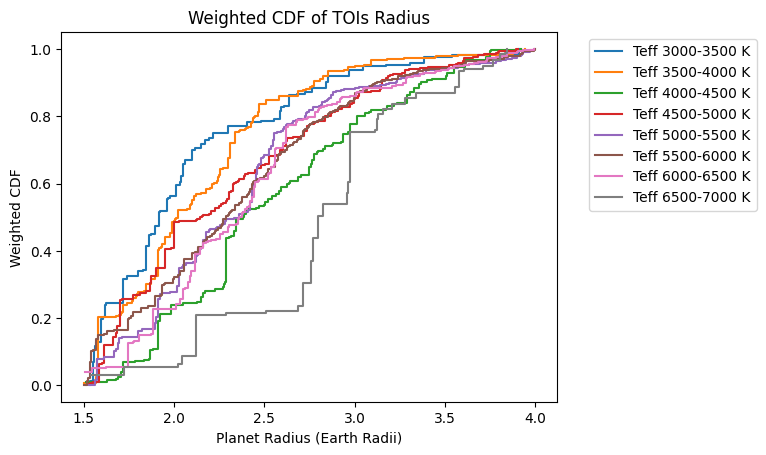

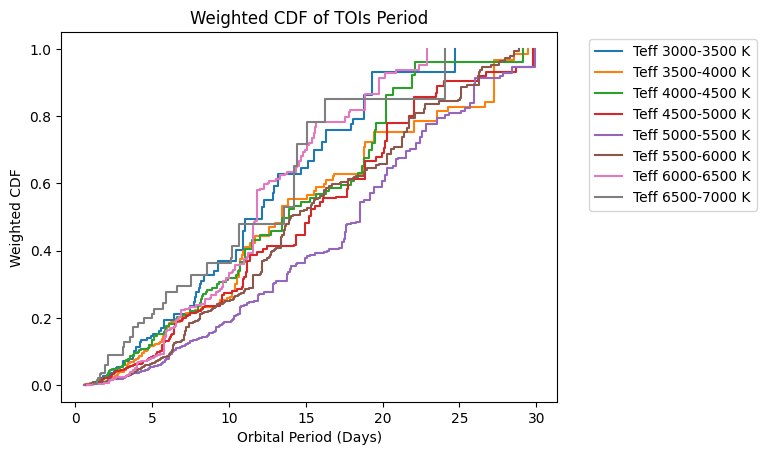

In [18]:
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    vals = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sort_idx = np.argsort(vals)
        vals_sorted = vals[sort_idx]
        weights_sorted = weights[sort_idx]
        cdf = np.cumsum(weights_sorted) / weights_sorted.sum()
        plt.step(vals_sorted, cdf, where='post', label=f'Teff {temp_range[0]}-{temp_range[1]} K')
plt.xlabel('Planet Radius (Earth Radii)')
plt.ylabel('Weighted CDF')
plt.title('Weighted CDF of TOIs Radius')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    vals = teff_df['pl_orbper'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sort_idx = np.argsort(vals)
        vals_sorted = vals[sort_idx]
        weights_sorted = weights[sort_idx]
        cdf = np.cumsum(weights_sorted) / weights_sorted.sum()
        plt.step(vals_sorted, cdf, where='post', label=f'Teff {temp_range[0]}-{temp_range[1]} K')
plt.xlabel('Orbital Period (Days)')
plt.ylabel('Weighted CDF')
plt.title('Weighted CDF of TOIs Period')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


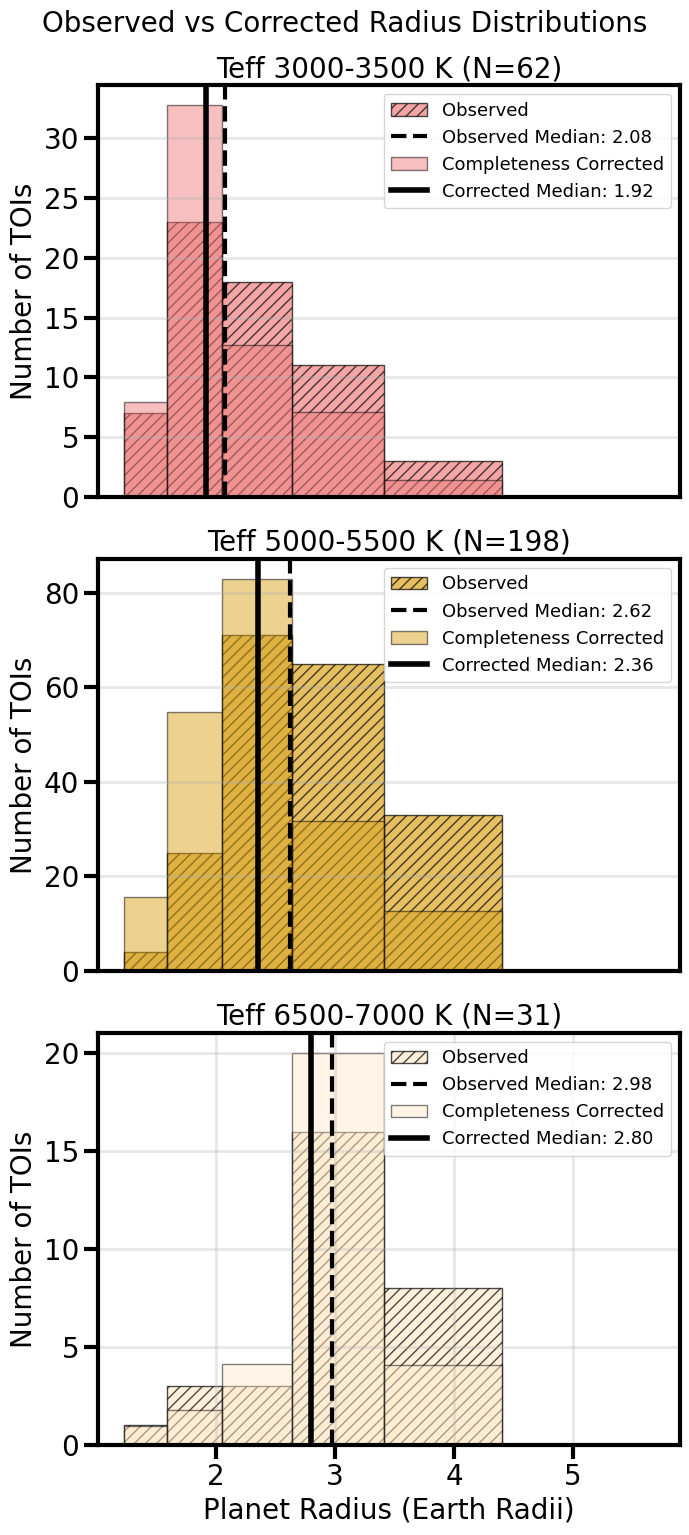

In [19]:
#### COMBINED RADIUS HISTOGRAMS - Three vertical panels ####
fig, axes = plt.subplots(3, 1, figsize=(7, 15))
# Define colors for each temperature range
colors = ['lightcoral', 'goldenrod', 'blanchedalmond']
teff_ranges = [(3000, 3500), (5000, 5500), (6500, 7000)]
for i, temp_range in enumerate(teff_ranges):
    ax = axes[i]
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]

    if len(teff_df) > 0:
        # Normal histogram (hatched)
        n_normal, bins_normal, patches_normal = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.7, 
            label='Observed', 
            color=colors[i],
            edgecolor='black',
            linewidth=1,
            hatch='///'  # Diagonal hatching for observed
        )

        # Calculate and plot normal median
        normal_median = teff_df['pl_rade'].median()
        ax.axvline(normal_median, linestyle='--', linewidth=3, color='black', 
                  label=f'Observed Median: {normal_median:.2f}')

        # Calculate normalized weights for corrected histogram
        # Scale weights so total weighted count equals total observed count
        weights = teff_df['weight'].values
        total_weight = weights.sum()
        n_observed = len(teff_df)
        normalized_weights = weights * (n_observed / total_weight) if total_weight > 0 else weights

        # Corrected histogram (solid)
        n_corrected, bins_corrected, patches_corrected = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.5, 
            label='Completeness Corrected', 
            weights=normalized_weights,
            color=colors[i],
            edgecolor='black',
            linewidth=1
        )

        # Calculate and plot weighted median (using original weights for median calculation)
        vals = teff_df['pl_rade'].values
        original_weights = teff_df['weight'].values
        if len(vals) > 0 and original_weights.sum() > 0:
            sorted_idx = np.argsort(vals)
            vals_sorted = vals[sorted_idx]
            weights_sorted = original_weights[sorted_idx]
            cumsum = np.cumsum(weights_sorted)
            cutoff = weights_sorted.sum() / 2.0
            weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
            ax.axvline(weighted_median, linestyle='-', linewidth=4, color='black', 
                      label=f'Corrected Median: {weighted_median:.2f}')

    ax.set_ylabel('Number of TOIs', fontsize=20)
    ax.set_title(f'Teff {temp_range[0]}-{temp_range[1]} K (N={len(teff_df)})', fontsize=20)
    ax.legend(fontsize=13)
    ax.grid(True, alpha=0.3, linewidth=2)
    ax.tick_params(axis='both', which='major', width=3, length=10, labelsize=20)
    ax.tick_params(axis='both', which='minor', width=2, length=6, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    if i < 2:
        ax.xaxis.set_ticks([])      # Remove x tick marks for top two panels
        ax.set_xlabel('')           # Remove x axis label for top two panels
    else:
        ax.set_xlabel('Planet Radius (Earth Radii)', fontsize=20)
plt.subplots_adjust(hspace=0)  # Negative hspace to make plots overlap vertically
plt.tight_layout()
plt.suptitle('Observed vs Corrected Radius Distributions', y=1.02, fontsize=20)
plt.show()

# Save the figure to a PNG file
fig.savefig("combined_radius_histograms.png", dpi=300, bbox_inches='tight')

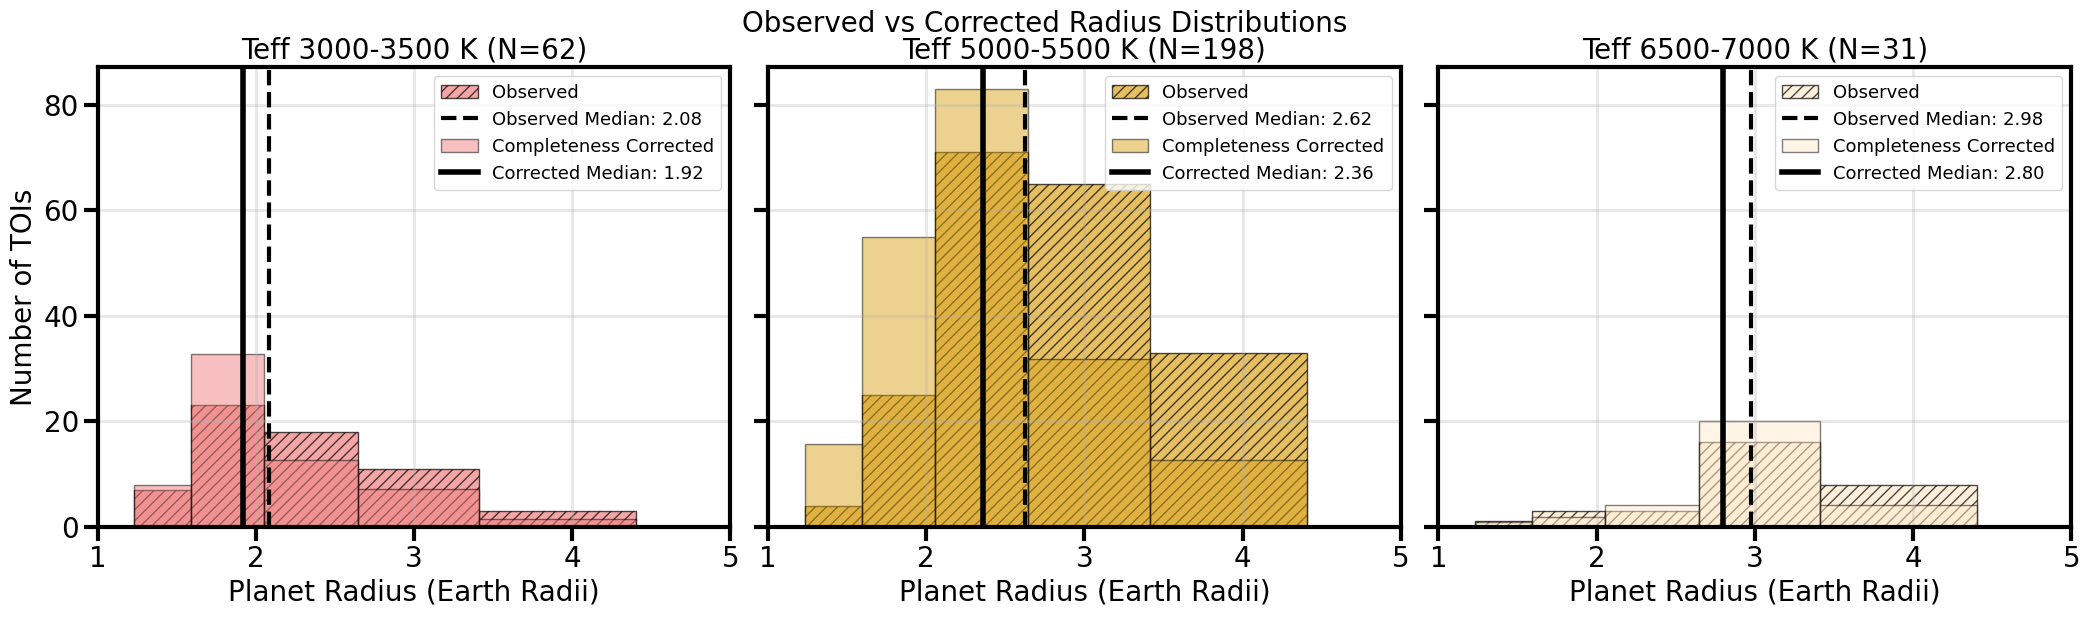

In [20]:
#### COMBINED RADIUS HISTOGRAMS - Three horizontal panels ####
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
# Define colors for each temperature range
colors = ['lightcoral', 'goldenrod', 'blanchedalmond']
teff_ranges = [(3000, 3500), (5000, 5500), (6500, 7000)]
for i, temp_range in enumerate(teff_ranges):
    ax = axes[i]
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]

    if len(teff_df) > 0:
        # Normal histogram (hatched)
        n_normal, bins_normal, patches_normal = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.7, 
            label='Observed', 
            color=colors[i],
            edgecolor='black',
            linewidth=1,
            hatch='///'  # Diagonal hatching for observed
        )

        # Calculate and plot normal median
        normal_median = teff_df['pl_rade'].median()
        ax.axvline(normal_median, linestyle='--', linewidth=3, color='black', 
                  label=f'Observed Median: {normal_median:.2f}')

        # Calculate normalized weights for corrected histogram
        # Scale weights so total weighted count equals total observed count
        weights = teff_df['weight'].values
        total_weight = weights.sum()
        n_observed = len(teff_df)
        normalized_weights = weights * (n_observed / total_weight) if total_weight > 0 else weights

        # Corrected histogram (solid)
        n_corrected, bins_corrected, patches_corrected = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.5, 
            label='Completeness Corrected', 
            weights=normalized_weights,
            color=colors[i],
            edgecolor='black',
            linewidth=1
        )

        # Calculate and plot weighted median (using original weights for median calculation)
        vals = teff_df['pl_rade'].values
        original_weights = teff_df['weight'].values
        if len(vals) > 0 and original_weights.sum() > 0:
            sorted_idx = np.argsort(vals)
            vals_sorted = vals[sorted_idx]
            weights_sorted = original_weights[sorted_idx]
            cumsum = np.cumsum(weights_sorted)
            cutoff = weights_sorted.sum() / 2.0
            weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
            ax.axvline(weighted_median, linestyle='-', linewidth=4, color='black', 
                      label=f'Corrected Median: {weighted_median:.2f}')

    ax.set_xlabel('Planet Radius (Earth Radii)', fontsize=20)
    ax.set_xlim(1, 5.0)
    ax.set_title(f'Teff {temp_range[0]}-{temp_range[1]} K (N={len(teff_df)})', fontsize=20)
    ax.legend(fontsize=13)
    ax.grid(True, alpha=0.3, linewidth=2)
    ax.tick_params(axis='both', which='major', width=3, length=10, labelsize=20)
    ax.tick_params(axis='both', which='minor', width=2, length=6, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    
    # Only show y-axis label on leftmost panel
    if i == 0:
        ax.set_ylabel('Number of TOIs', fontsize=20)

plt.subplots_adjust(wspace=0.05)  # Small spacing between horizontal panels
plt.tight_layout()
plt.suptitle('Observed vs Corrected Radius Distributions', y=1.02, fontsize=20)
plt.show()

# Save the figure to a PNG file
fig.savefig("combined_radius_histograms.png", dpi=300, bbox_inches='tight')